In [1]:
%load_ext autoreload
%autoreload 2


import glob
import os
import ozy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import pandas as pd
from collections import defaultdict


   ___                                           _  _             
  /___\ ____ _   _  _ __ ___    __ _  _ __    __| |(_)  __ _  ___ 
 //  //|_  /| | | || '_ ` _ \  / _` || '_ \  / _` || | / _` |/ __|
/ \_//  / / | |_| || | | | | || (_| || | | || (_| || || (_| |\__ \
\___/  /___| \__, ||_| |_| |_| \__,_||_| |_| \__,_||_| \__,_||___/
             |___/                                                

   (C) 2021 F. Rodriguez Montero
   Version 0.2.dev1



In [2]:
directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/'
ozy_files = []
for filename in glob.glob(os.path.join(directory, '*.hdf5')):
    ozy_files.append(filename)

ozy_file = ozy_files[0]

print(ozy_file)

/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/ozy_00925.hdf5


1
For Galaxy: 24
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_24.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_24.hdf5
4433764
1079307
44338


/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/mnt/users/darnej/miniconda3/envs/ozyenv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN found 2 galaxy cores.
Cluster center of mass: (3.987278028040267, -20.063363825501018, -2.4117010056439727)
Cluster center of mass: (-1.2552959047385277, 6.575446506665021, 0.5882680385503886)


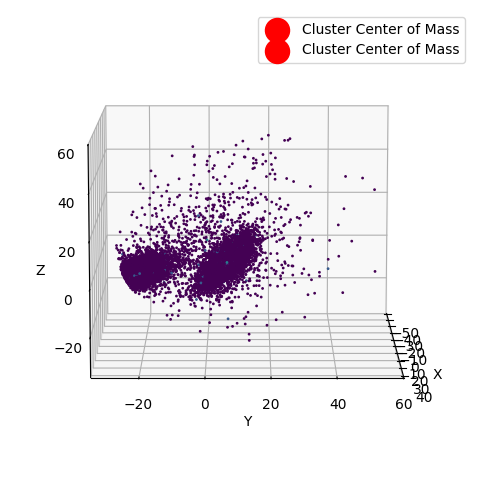

In [6]:
gals = np.loadtxt("/mnt/users/darnej/MPhys/Chosen_galaxies.txt")
import math
import hdbscan

gals = [24]

print(len(gals))

for gal in gals:

    gal_num = int(gal)


    print('For Galaxy:', gal_num)

    directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/'

    stars_files = []
    for filename in glob.glob(os.path.join(directory, '*star*_' + str(gal_num) + '.hdf5')):
        stars_files.append(filename)

    dm_files = []
    for filename in glob.glob(os.path.join(directory, '*dm*_' + str(gal_num) + '.hdf5')):
        dm_files.append(filename)

    from dynamics import load_data

    star_filename = stars_files[0]
    dm_filename = dm_files[0]
    print(star_filename)
    print(dm_filename)

    star_data, dm_data, mass_multiplier, length_multiplier, time_multiplier = load_data(star_filename, dm_filename, ozy_file)

    xdata = star_data['x'].value
    ydata = star_data['y'].value
    zdata = star_data['z'].value
    massdata = star_data['mass'].value

    positions = np.column_stack((xdata, ydata, zdata))


    positions = positions[::100]
    massdata = massdata[::100]


    print(len(positions))



    clusterer = hdbscan.HDBSCAN(min_cluster_size=math.ceil(len(positions)/30), min_samples=math.ceil(len(positions)/500), cluster_selection_epsilon=0.1, cluster_selection_method='eom', allow_single_cluster=True)
    #min samples: how many points need to be near eachother to be considered a valid starting point for a cluster
    #min cluster size: how many points need to be in a cluster for it to be considered a valid cluster
    labels = clusterer.fit_predict(positions)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"HDBSCAN found {n_clusters} galaxy cores.")


    # Compute center of mass of the most massive cluster
    cluster_masses = {}
    cluster_positions = {}


    fig, ax = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(10, 6))

    for label in set(labels):
        if label == -1:
            continue
        mask = labels == label

        cluster_cm_x = np.mean(positions[mask, 0])
        cluster_cm_y = np.mean(positions[mask, 1])
        cluster_cm_z = np.mean(positions[mask, 2])
    
        print(f"Cluster center of mass: ({cluster_cm_x}, {cluster_cm_y}, {cluster_cm_z})")

        ax.scatter(cluster_cm_x, cluster_cm_y, cluster_cm_z, c='red', s=300, label='Cluster Center of Mass')



    ax.scatter(positions[:,0], positions[:,1], positions[:,2], c = np.log10(massdata), alpha = 1, s = 1)


    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=10, azim=0)
    plt.legend()
    plt.show()





1
For Galaxy: 14
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_14.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_14.hdf5
19272347
4653372


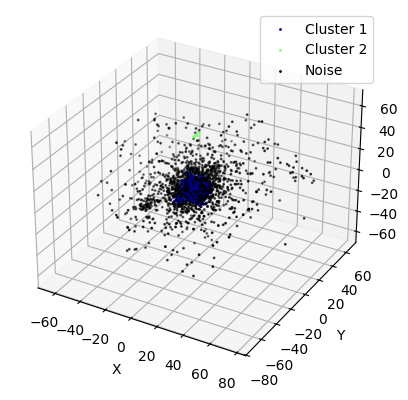

Galaxy 1 has 2 core(s)


In [7]:
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def detect_cores(points, eps=3, min_samples=20, visualize=True):
    """
    Detects number of galaxy cores in a 3D point cloud using DBSCAN.

    Args:
        points (np.ndarray): Nx3 array of 3D coordinates.
        eps (float): DBSCAN epsilon (neighborhood size).
        min_samples (int): Minimum samples in a core point.
        visualize (bool): If True, shows a 3D scatter plot with clusters.

    Returns:
        int: Number of detected cores (clusters).
    """
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(points)
    labels = clustering.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if visualize:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        for label in set(labels):
            if label == -1:
                color = 'k'
                label_name = 'Noise'
            else:
                color = plt.cm.jet(label / n_clusters)
                label_name = f'Cluster {label + 1}'
            cluster_points = points[labels == label]
            ax.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2],
                       c=[color], s=1, label=label_name)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        plt.legend()
        plt.show()

    return n_clusters

gals = [14]

print(len(gals))

for gal in gals:

    gal_num = int(gal)


    print('For Galaxy:', gal_num)

    directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/'

    stars_files = []
    for filename in glob.glob(os.path.join(directory, '*star*_' + str(gal_num) + '.hdf5')):
        stars_files.append(filename)

    dm_files = []
    for filename in glob.glob(os.path.join(directory, '*dm*_' + str(gal_num) + '.hdf5')):
        dm_files.append(filename)

    from dynamics import load_data

    star_filename = stars_files[0]
    dm_filename = dm_files[0]
    print(star_filename)
    print(dm_filename)

    star_data, dm_data, mass_multiplier, length_multiplier, time_multiplier = load_data(star_filename, dm_filename, ozy_file)

    xdata = star_data['x'].value
    ydata = star_data['y'].value
    zdata = star_data['z'].value
    massdata = star_data['mass'].value

    positions = np.column_stack((xdata, ydata, zdata))


def downsample_points(points, fraction=0.1, seed=42):
    np.random.seed(seed)
    idx = np.random.choice(points.shape[0], int(fraction * points.shape[0]), replace=False)
    return points[idx]

positions = downsample_points(positions, fraction=5000/len(positions))

n_cores_g1 = detect_cores(positions, eps=3, min_samples=20)

print(f"Galaxy 1 has {n_cores_g1} core(s)")



In [9]:
possible_mergers = pd.read_csv('/mnt/users/darnej/MPhys/Removing_weirdos/possible_mergers_list.csv')

mask = np.array(possible_mergers)[:,2]


possible_mergers = np.array(possible_mergers)[:,0]

possible_mergers = possible_mergers[mask == False]

print(len(possible_mergers))
print(possible_mergers)

114
[20 66 52 72 49 96 545 80 137 57 11 38 480 259 1048 516 383 90 375 563 228
 8 1011 156 39 198 61 713 253 494 243 22 693 339 12 141 619 535 322 120
 610 499 149 187 92 162 25 108 106 69 182 51 547 13 89 968 413 47 200 36
 849 570 496 27 488 233 113 395 943 388 504 123 159 241 147 193 255 475
 165 999 427 290 752 152 184 328 396 379 128 493 657 478 188 508 594 14
 575 247 261 598 179 362 197 256 312 18 132 189 112 166 7 185 134 117]


For Galaxy: 20
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_20.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_20.hdf5
814347
92068


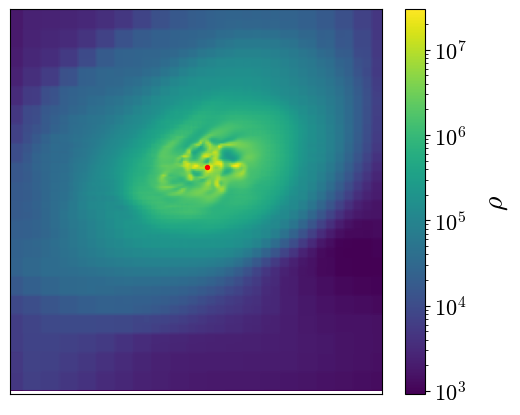

<Figure size 640x480 with 0 Axes>

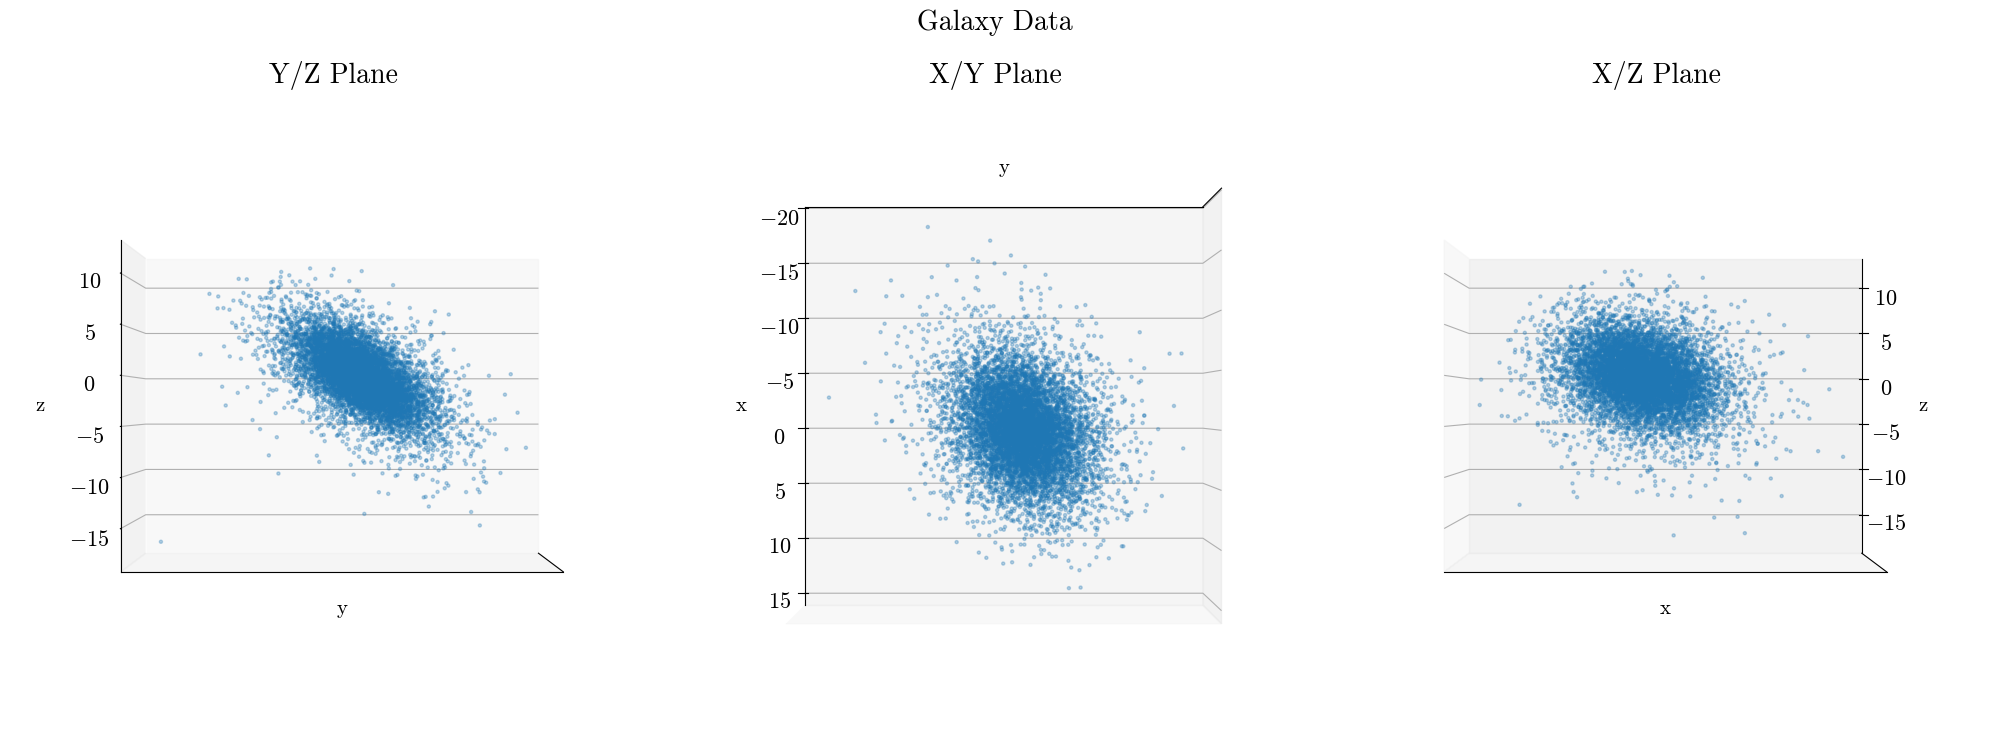

For Galaxy: 66
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_66.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_66.hdf5
472910
77099


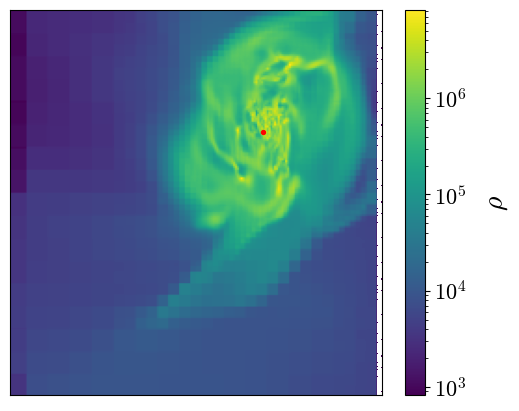

<Figure size 640x480 with 0 Axes>

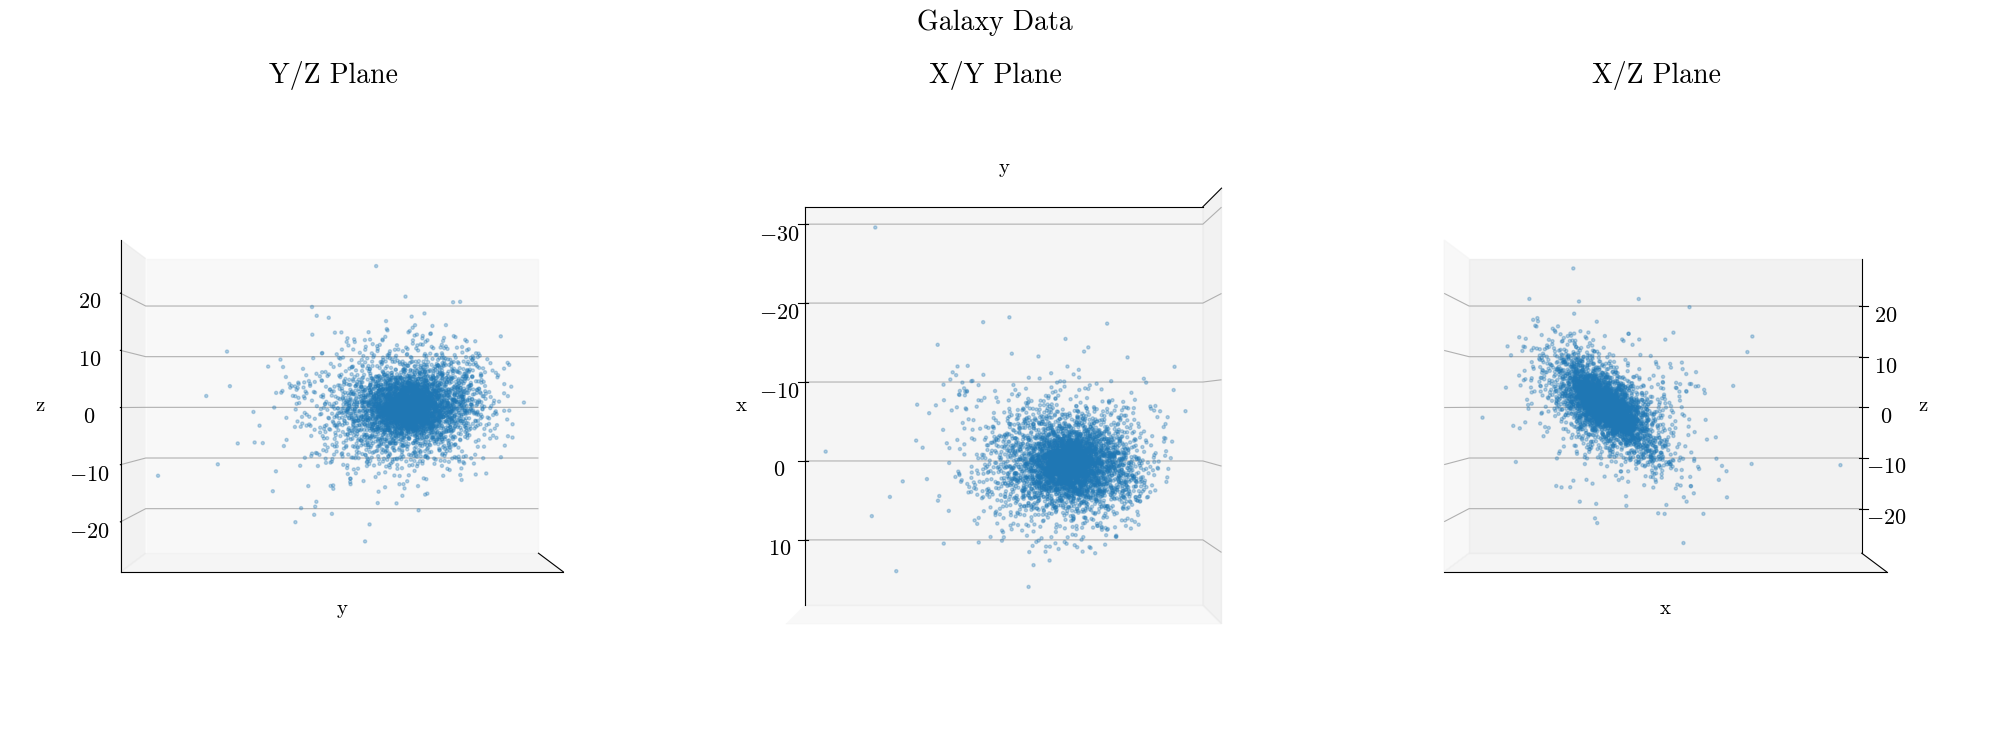

For Galaxy: 52
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_52.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_52.hdf5
119395
38368


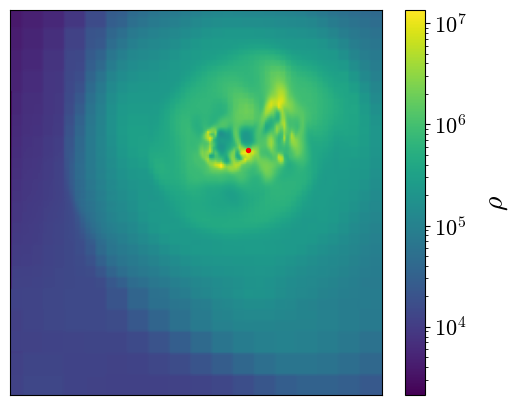

<Figure size 640x480 with 0 Axes>

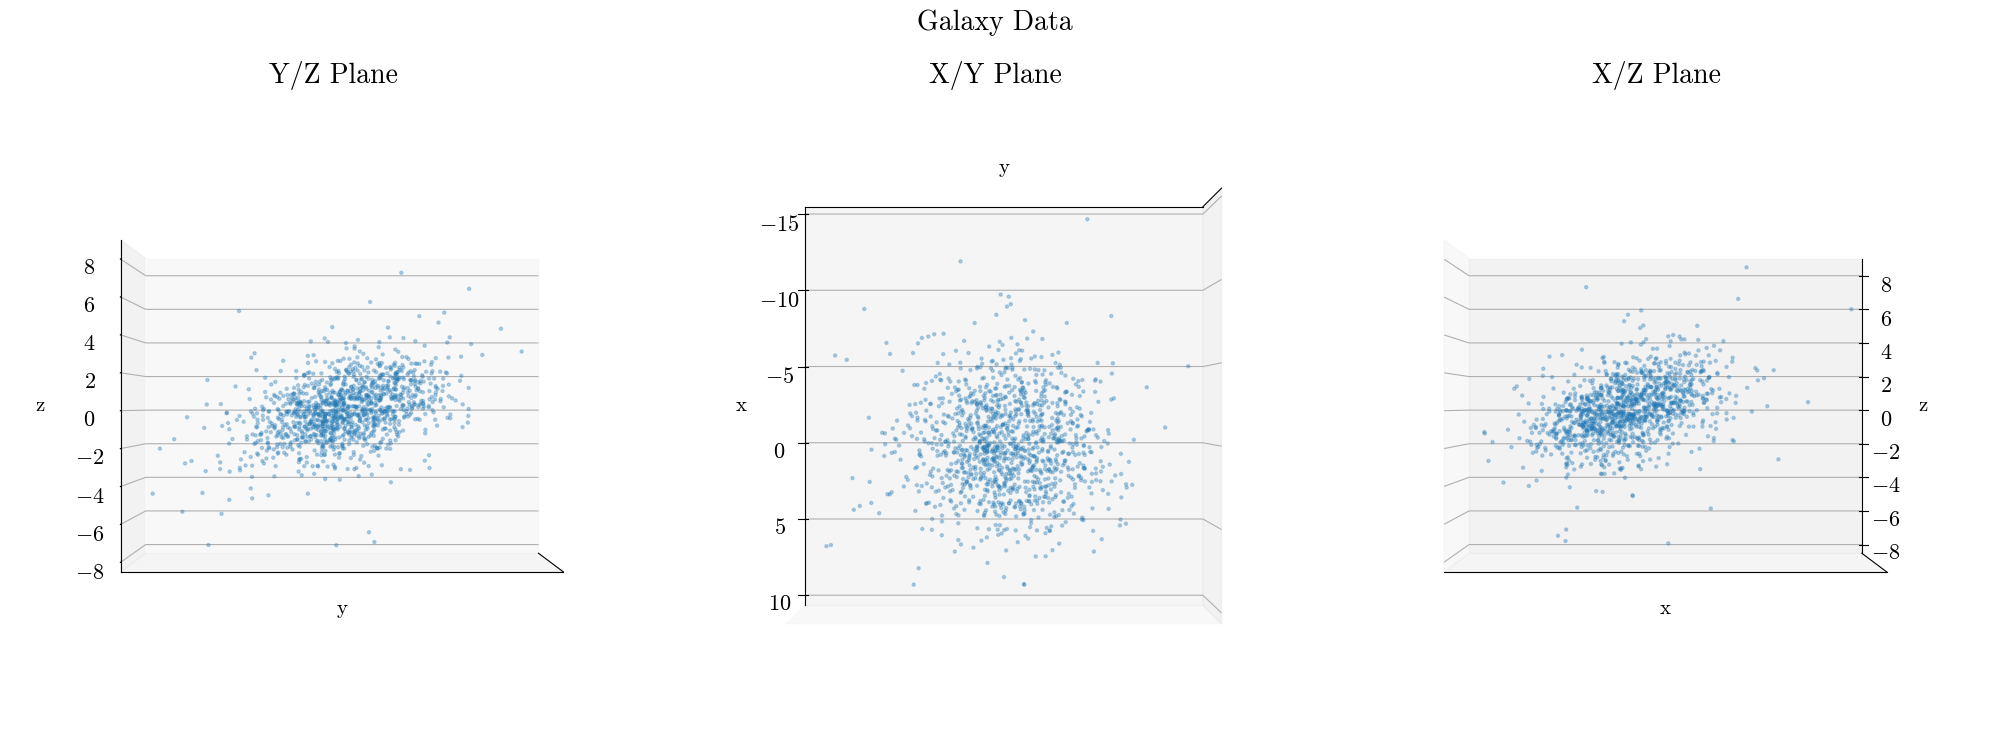

For Galaxy: 72
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_72.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_72.hdf5
42416
35682


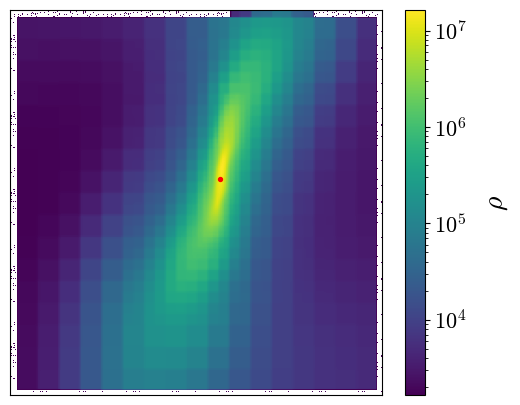

<Figure size 640x480 with 0 Axes>

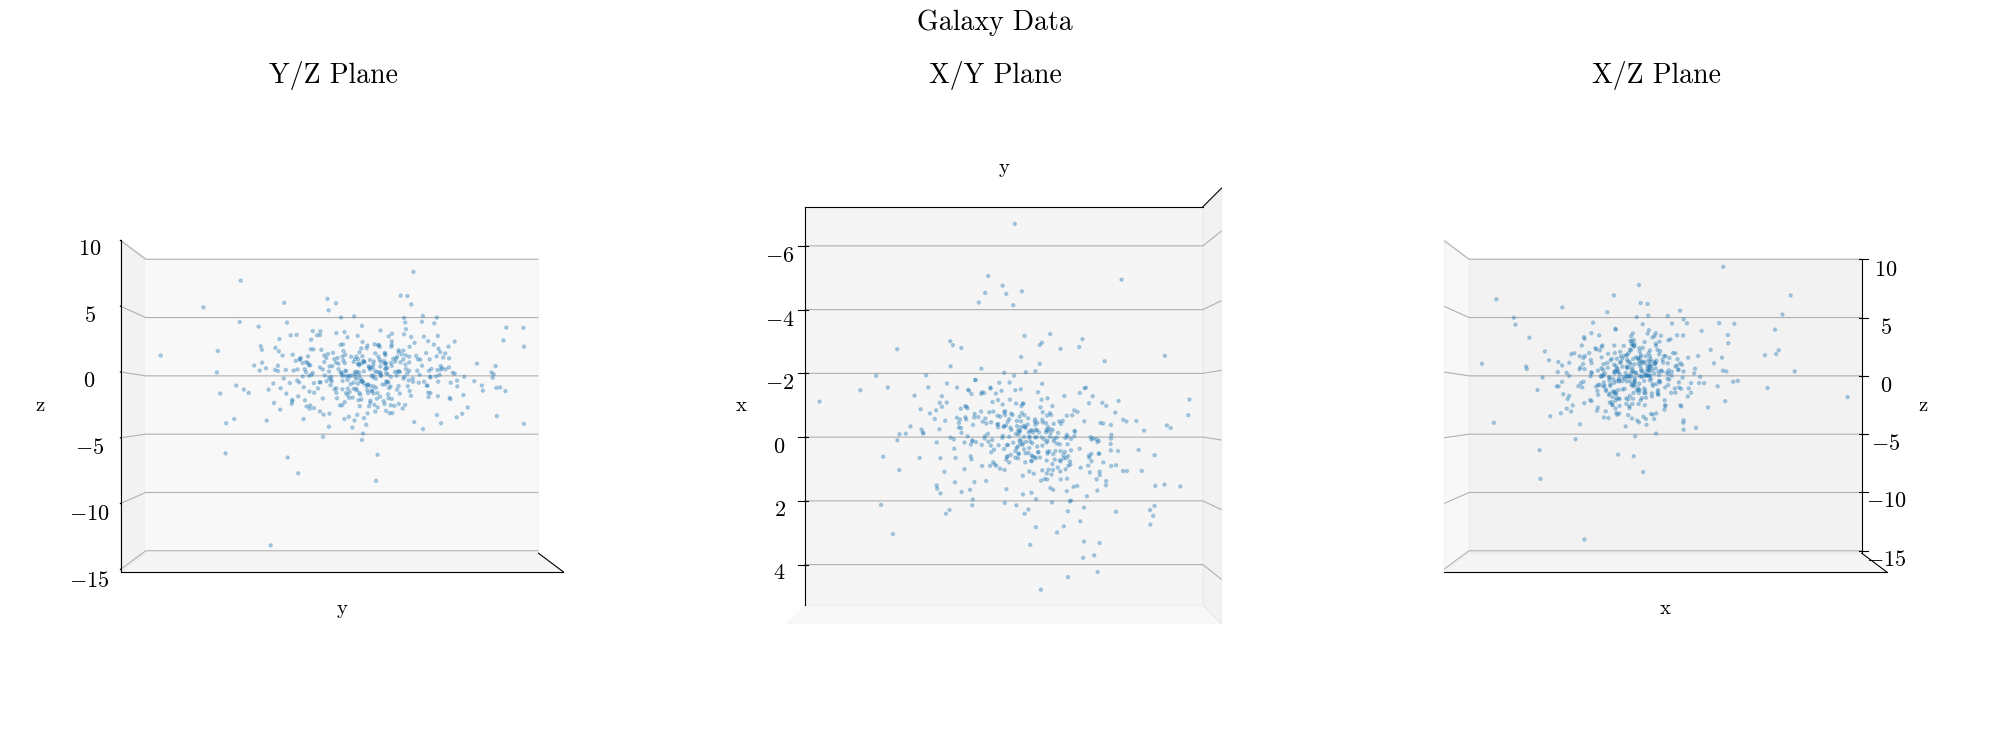

For Galaxy: 49
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_49.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_49.hdf5
221489
113238


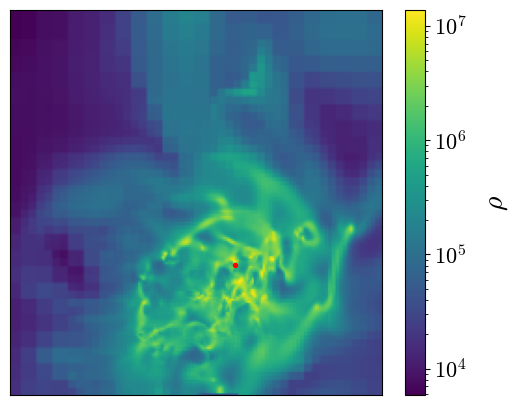

<Figure size 640x480 with 0 Axes>

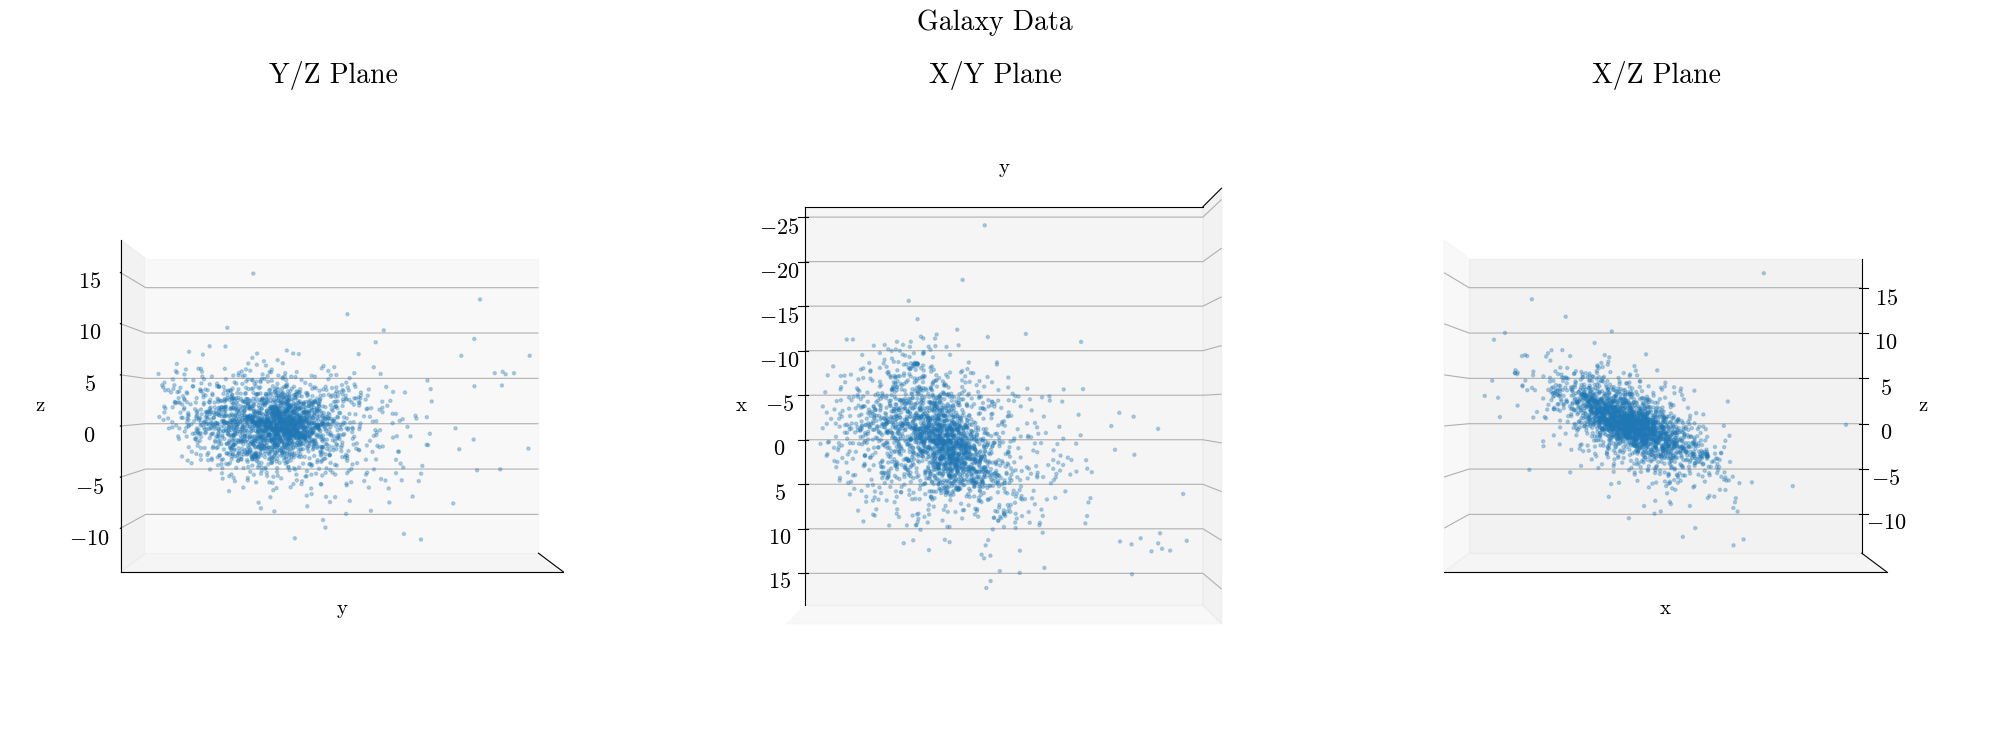

For Galaxy: 96
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_96.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_96.hdf5
69464
49443


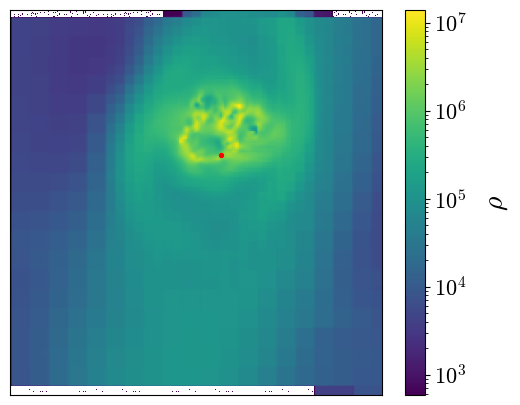

<Figure size 640x480 with 0 Axes>

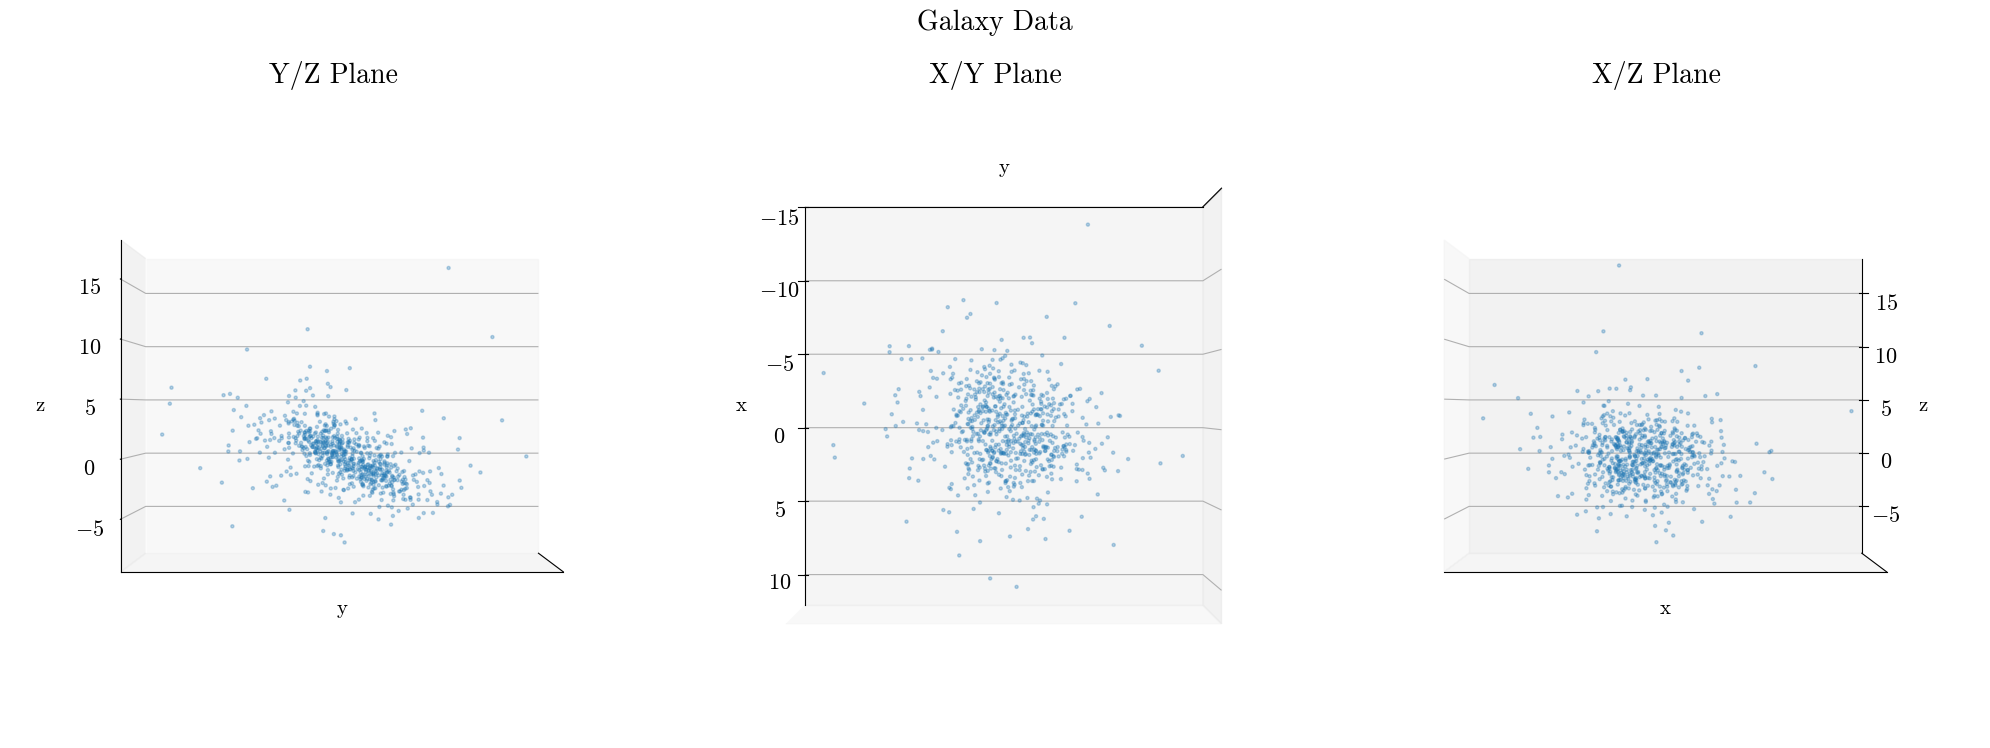

For Galaxy: 545
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_545.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_545.hdf5
14514
11826


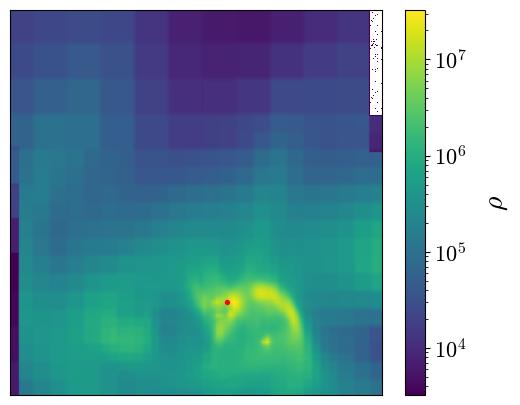

<Figure size 640x480 with 0 Axes>

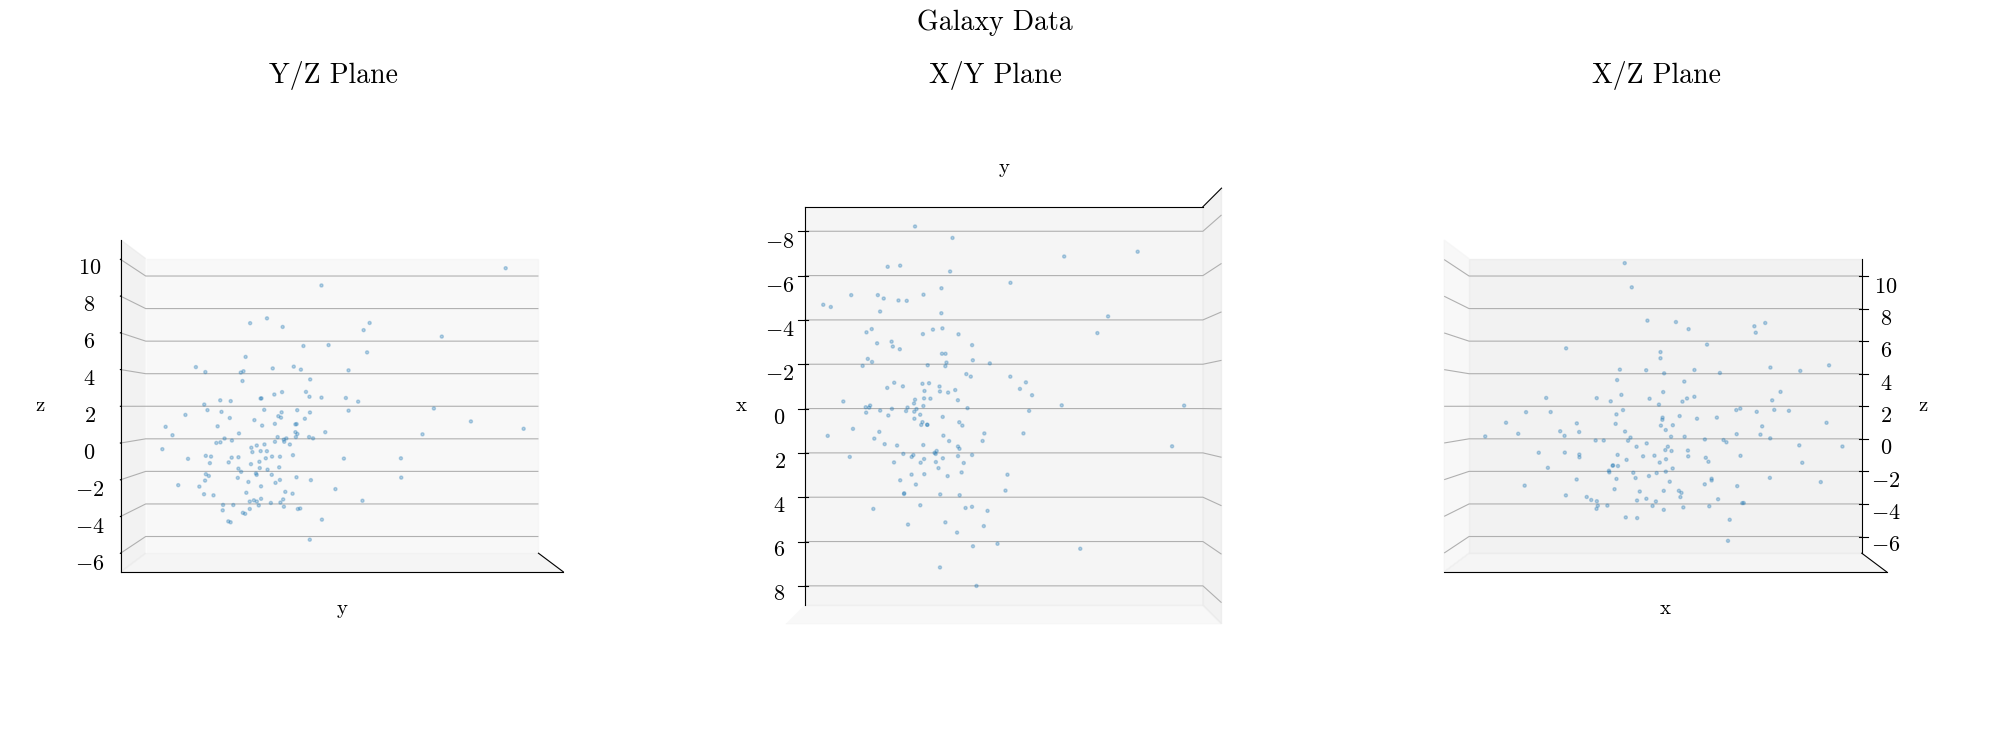

For Galaxy: 80
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_80.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_80.hdf5
433321
49582


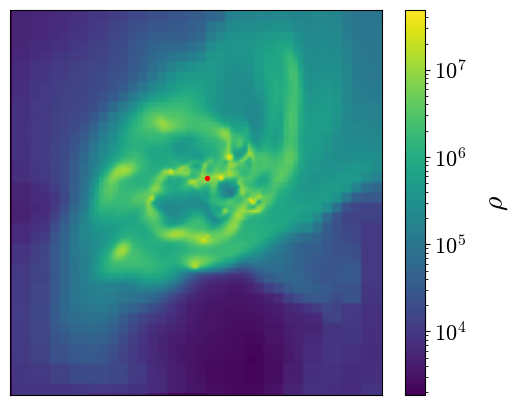

<Figure size 640x480 with 0 Axes>

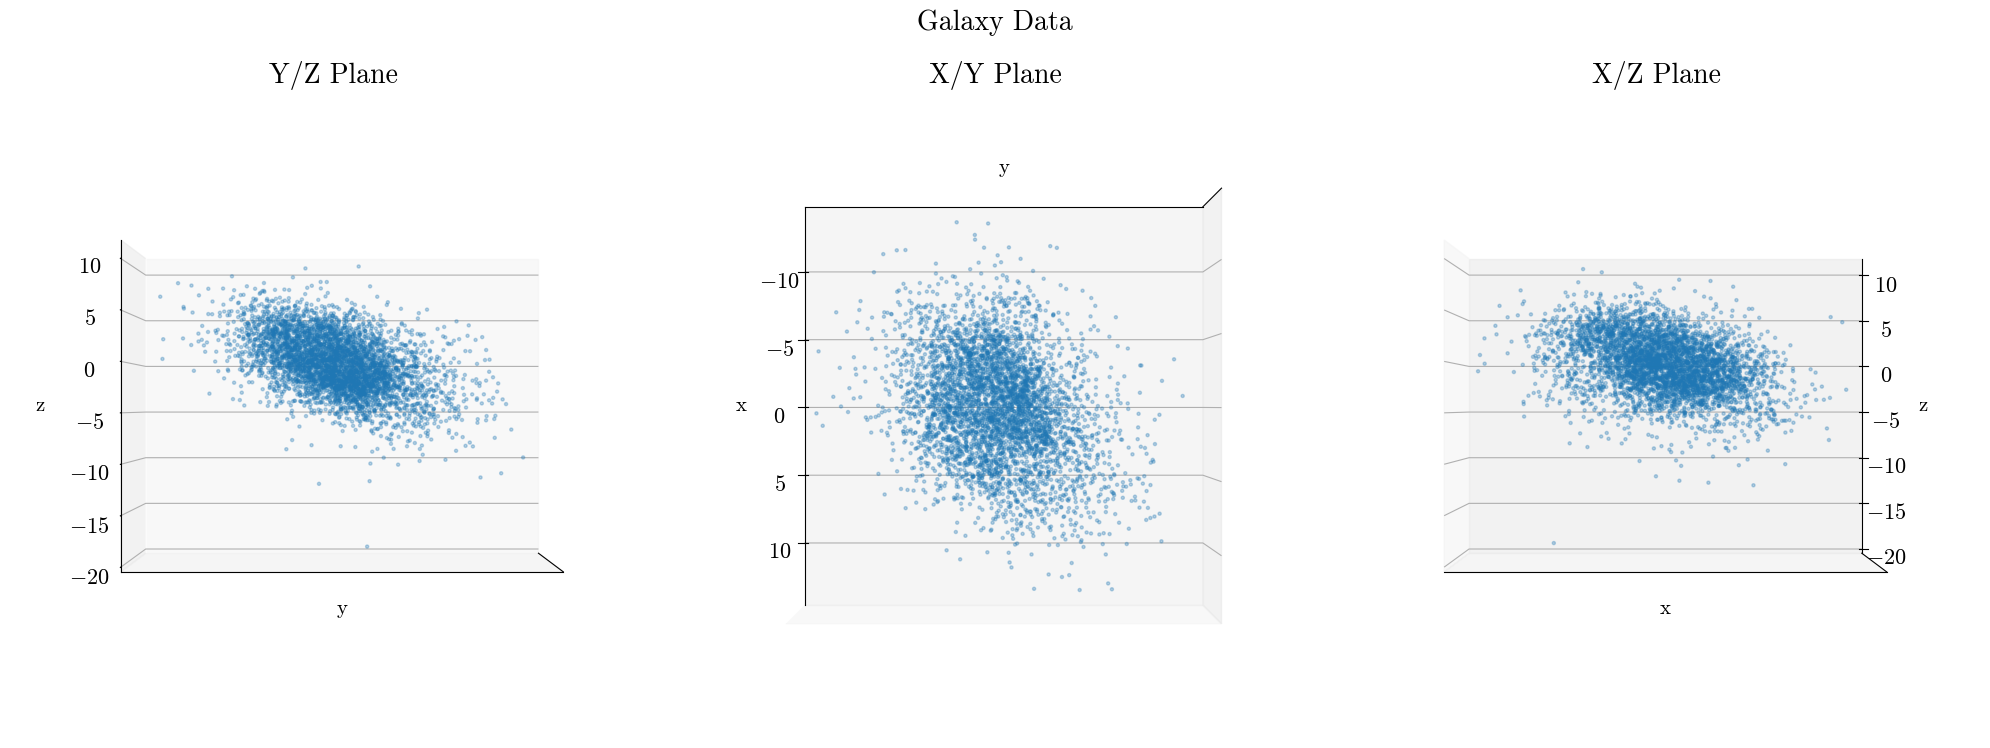

For Galaxy: 137
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_137.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_137.hdf5
430845
63651


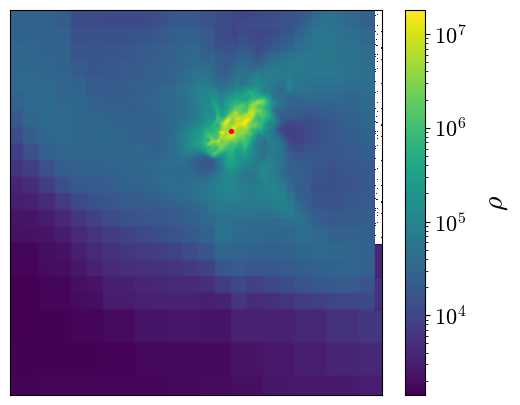

<Figure size 640x480 with 0 Axes>

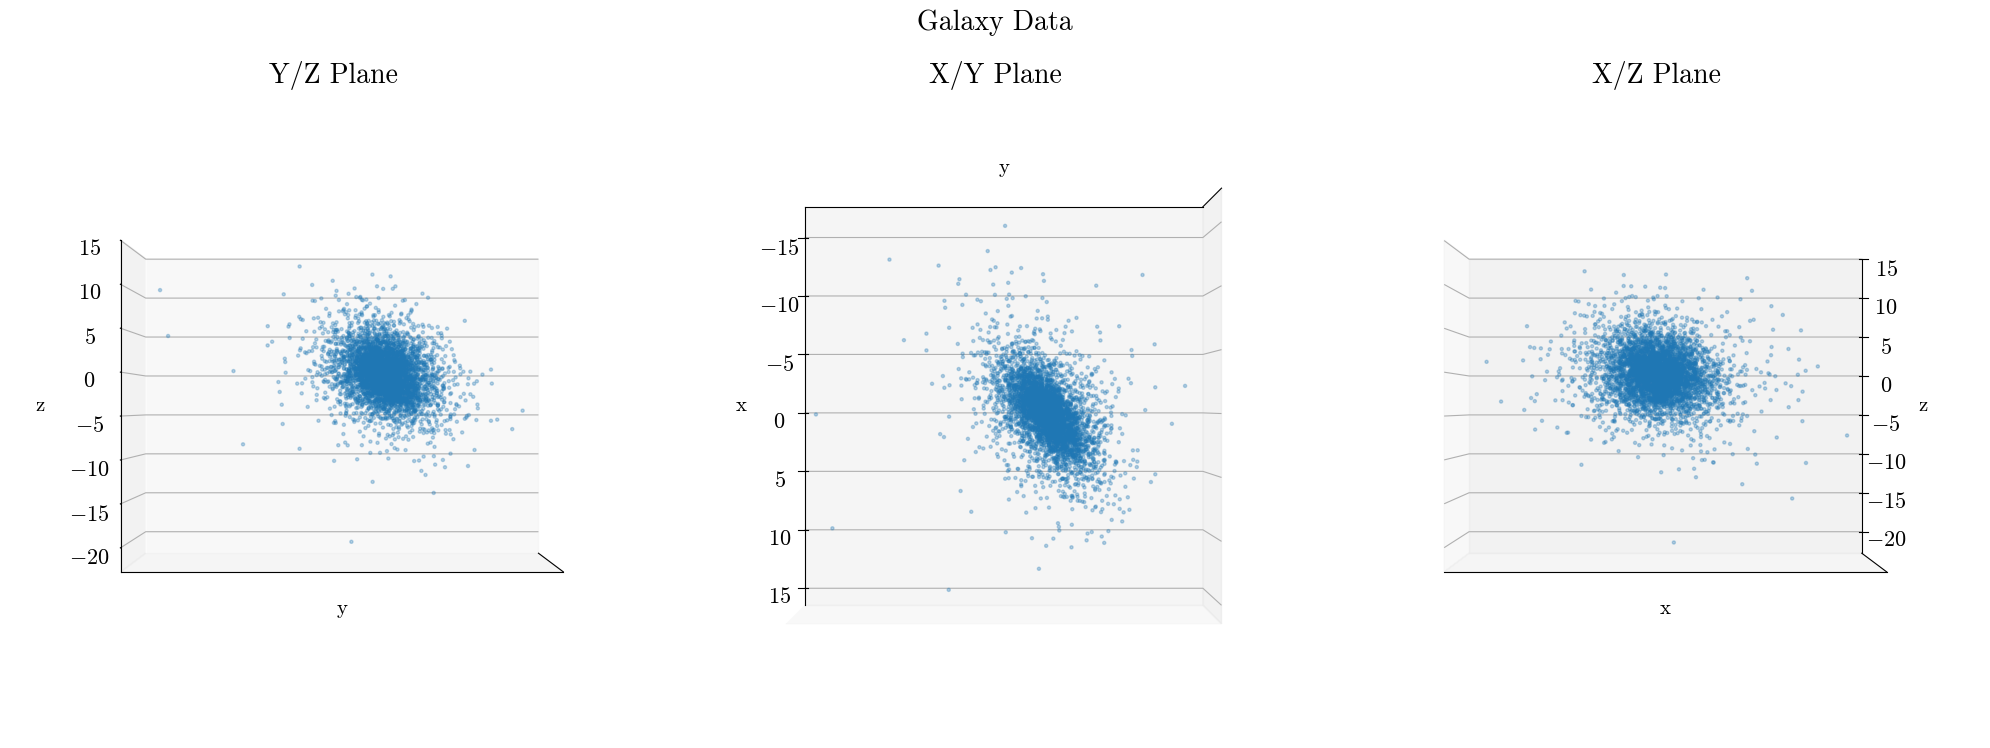

For Galaxy: 57
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_57.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_57.hdf5
1794475
221731


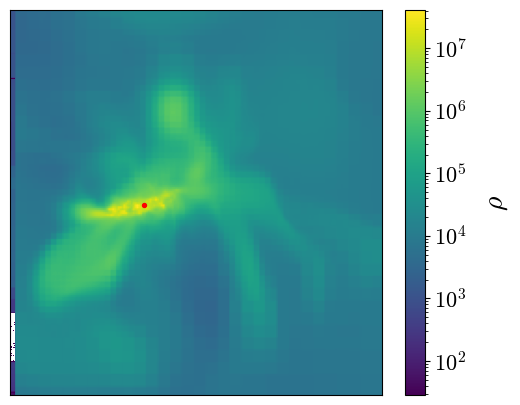

<Figure size 640x480 with 0 Axes>

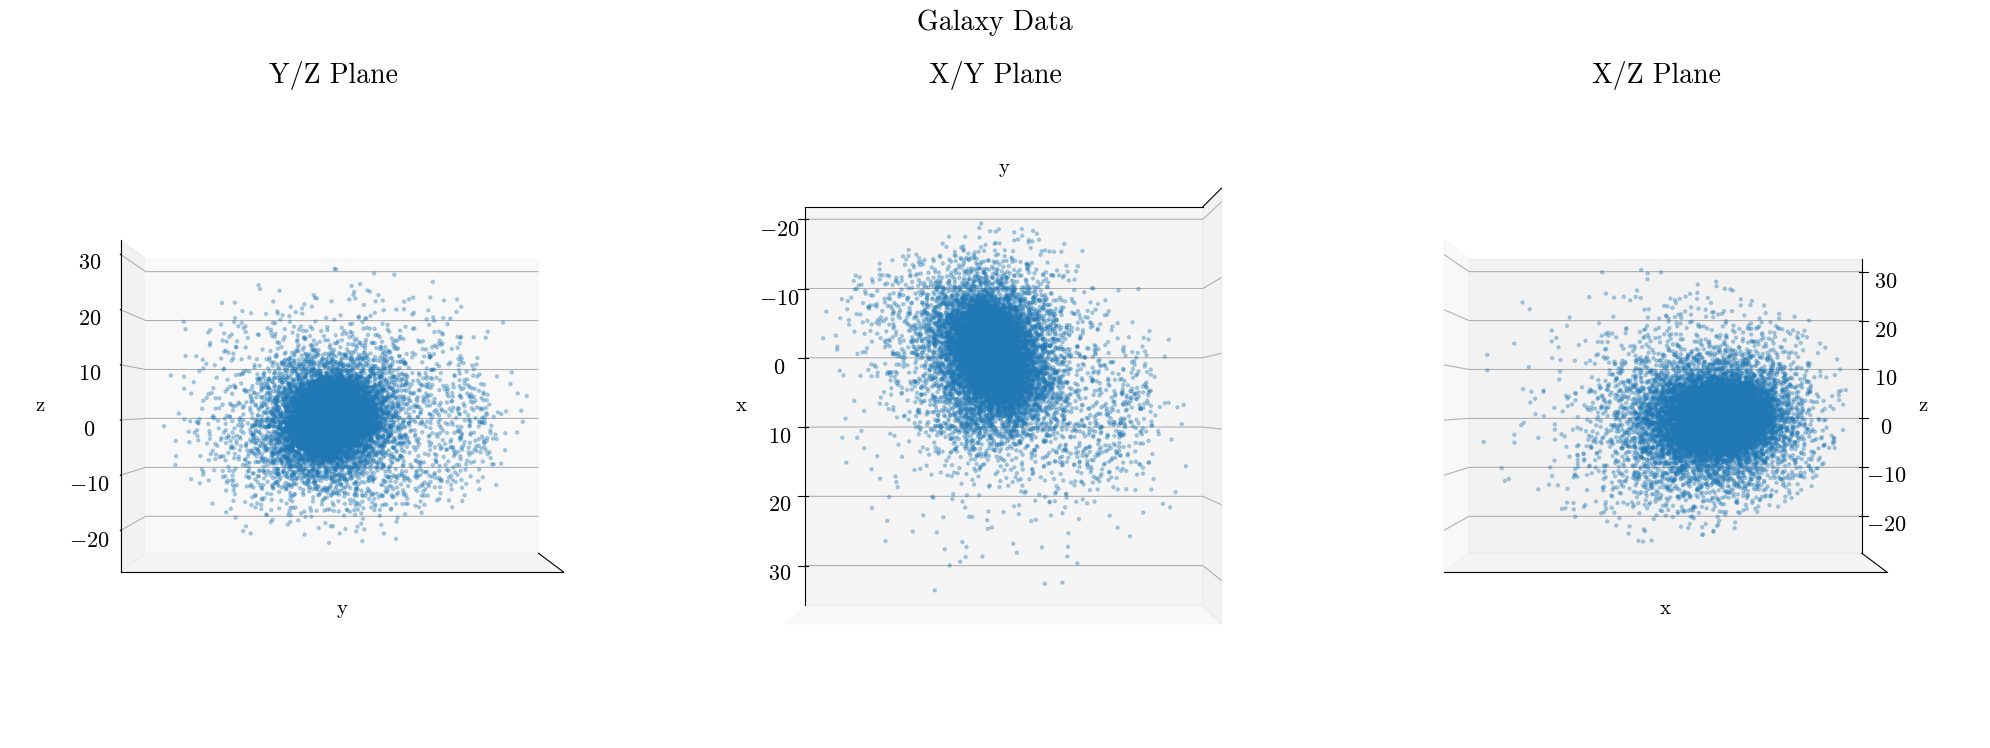

For Galaxy: 11
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_11.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_11.hdf5
3076474
577689


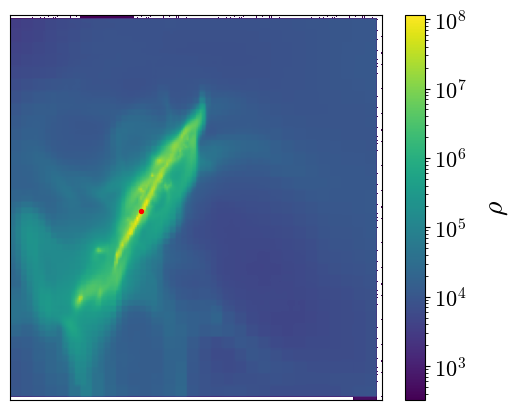

<Figure size 640x480 with 0 Axes>

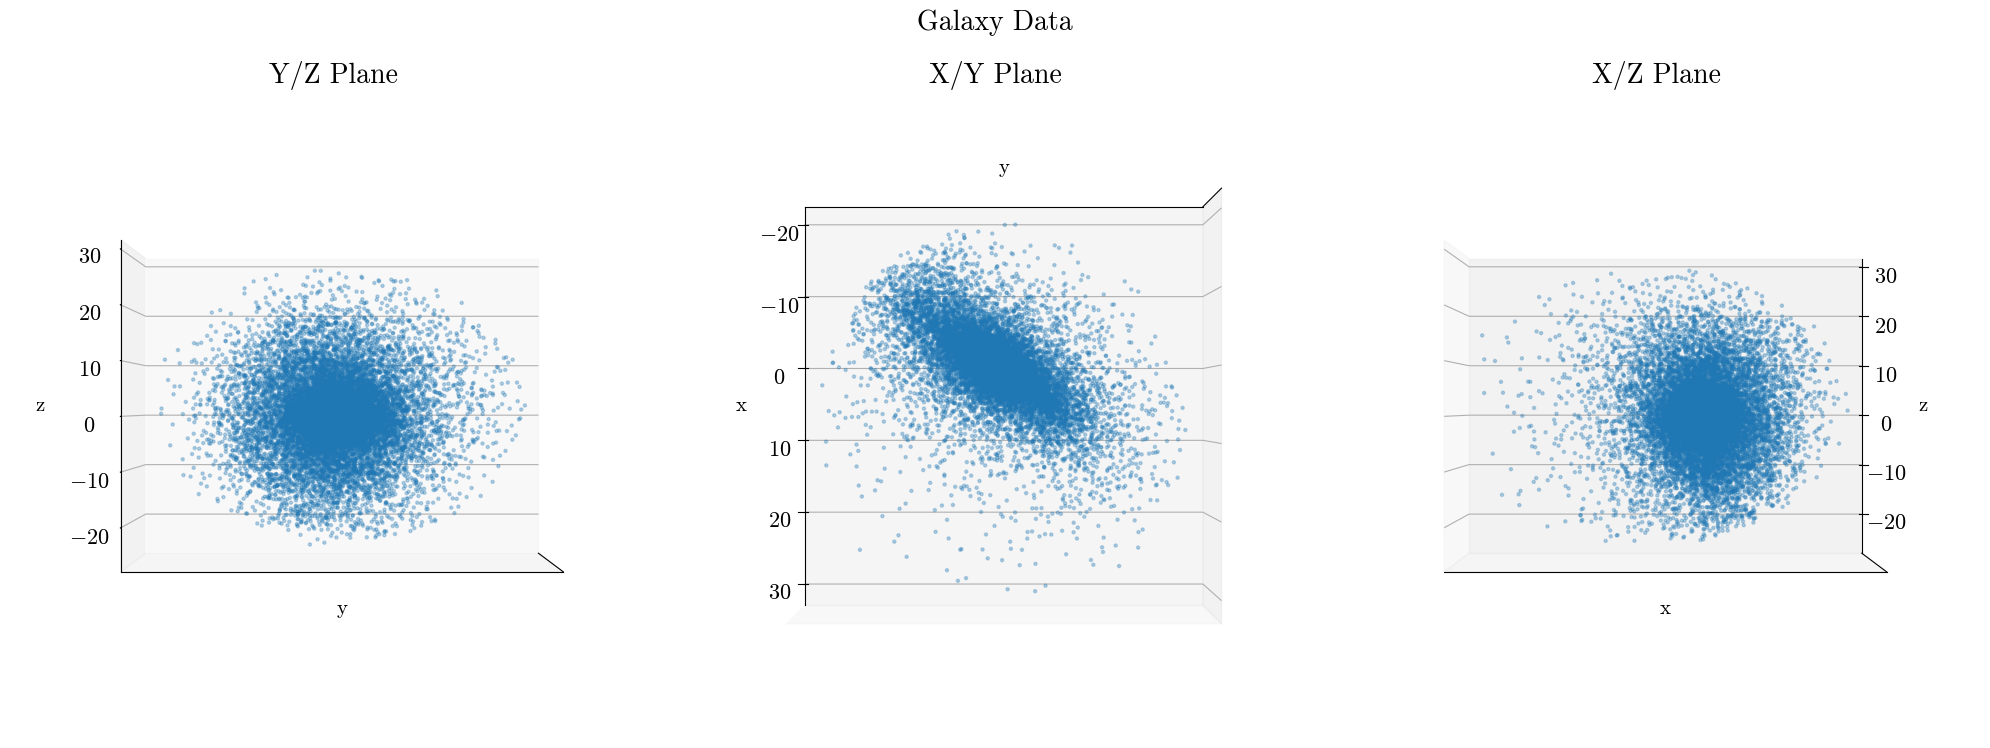

For Galaxy: 38
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_38.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_38.hdf5
3573580
618938


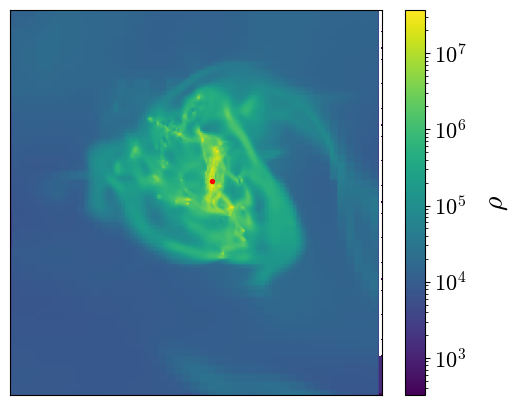

<Figure size 640x480 with 0 Axes>

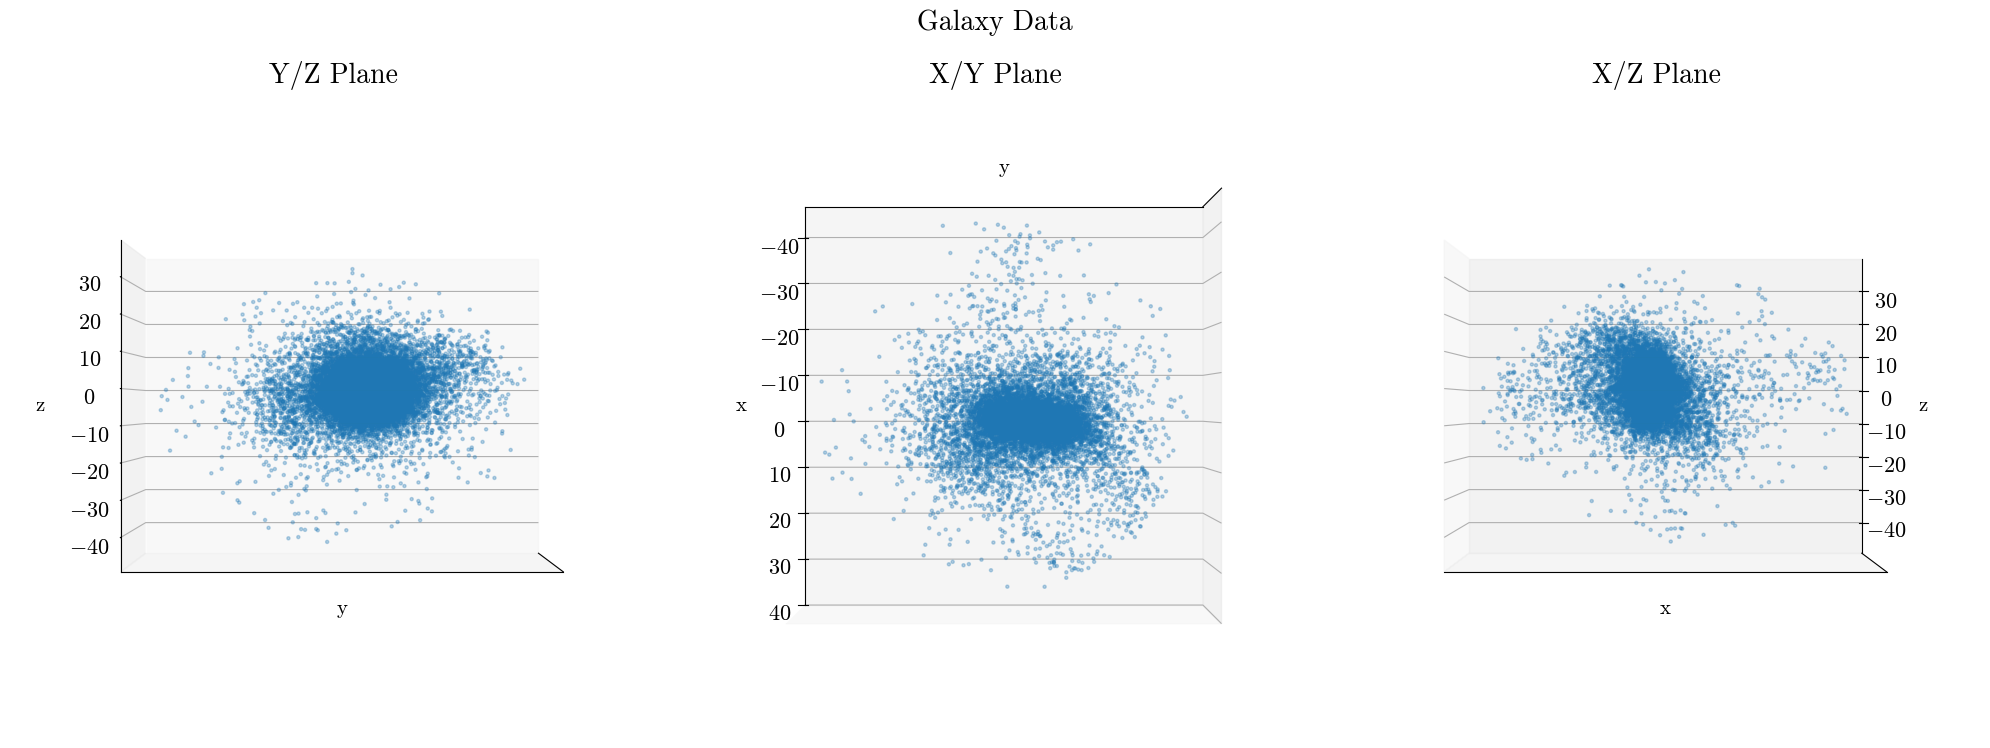

For Galaxy: 480
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_480.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_480.hdf5
6644
18108


KeyboardInterrupt: 

In [10]:
for gal in possible_mergers:

    gal_num = int(gal)

    print('For Galaxy:', gal_num)

    directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/'

    stars_files = []
    for filename in glob.glob(os.path.join(directory, '*star*_' + str(gal_num) + '.hdf5')):
        stars_files.append(filename)

    dm_files = []
    for filename in glob.glob(os.path.join(directory, '*dm*_' + str(gal_num) + '.hdf5')):
        dm_files.append(filename)

    from dynamics import load_data

    star_filename = stars_files[0]
    dm_filename = dm_files[0]
    print(star_filename)
    print(dm_filename)

    star_data, dm_data, mass_multiplier, length_multiplier, time_multiplier = load_data(star_filename, dm_filename, ozy_file)



    from dynamics import load_gas_data

    directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/gas_files/'

    files = glob.glob(os.path.join(directory, '*_' + str(gal_num) + '.hdf5'))


    gas_positions, gas_masses, gas_densities, gas_velocities = load_gas_data(files[0], ozy_file)


    xdata = star_data['x'].value
    ydata = star_data['y'].value
    zdata = star_data['z'].value

    vxdata = star_data['vx'].value
    vydata = star_data['vy'].value
    vzdata = star_data['vz'].value

    massdata = star_data['mass'].value

    from dynamics import Plot_3d_scatter



    Plot_3d_scatter(xdata, ydata, zdata, 'x', 'y', 'z', 'Galaxy Data')



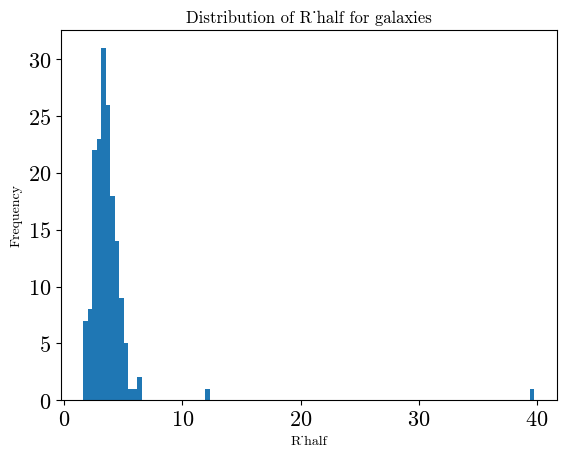

Top 5 galaxies with largest r_half:
322 with r_half = 5.431698546220815
162 with r_half = 6.010966516110851
2 with r_half = 6.205739230416152
112 with r_half = 6.223412761652948
594 with r_half = 11.961354117059953
185 with r_half = 39.78401592327208


In [6]:
#Check galaxies with large r_half

dataframe = pd.read_csv('/mnt/users/darnej/MPhys/galaxies_dataframe.csv')

r_half = dataframe['r_half']

chosen_gals = np.loadtxt("/mnt/users/darnej/MPhys/Chosen_galaxies.txt")
r_half = r_half[chosen_gals-1]

plt.hist(r_half, bins=100)
plt.xlabel('R_half')
plt.ylabel('Frequency')
plt.title('Distribution of R_half for galaxies')
plt.show()

#find the top 5 r_half gals

top_6_r_half_indices = np.argsort(r_half)[-6:]
top_6_gals = chosen_gals[top_6_r_half_indices]

print("Top 5 galaxies with largest r_half:")
for gal in top_6_gals:
    print(str(int(gal)) + ' with r_half = ' + str(r_half[int(gal)-1]))


For Galaxy: 322
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_322.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_322.hdf5
172848
46635


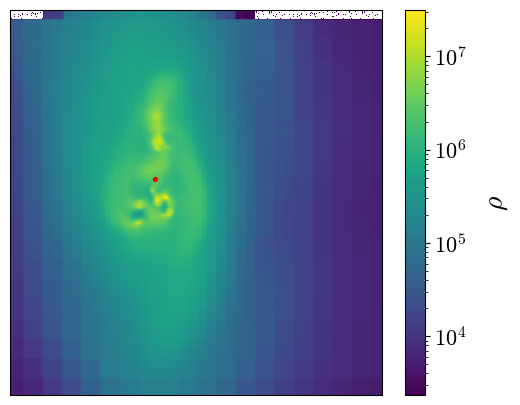

<Figure size 640x480 with 0 Axes>

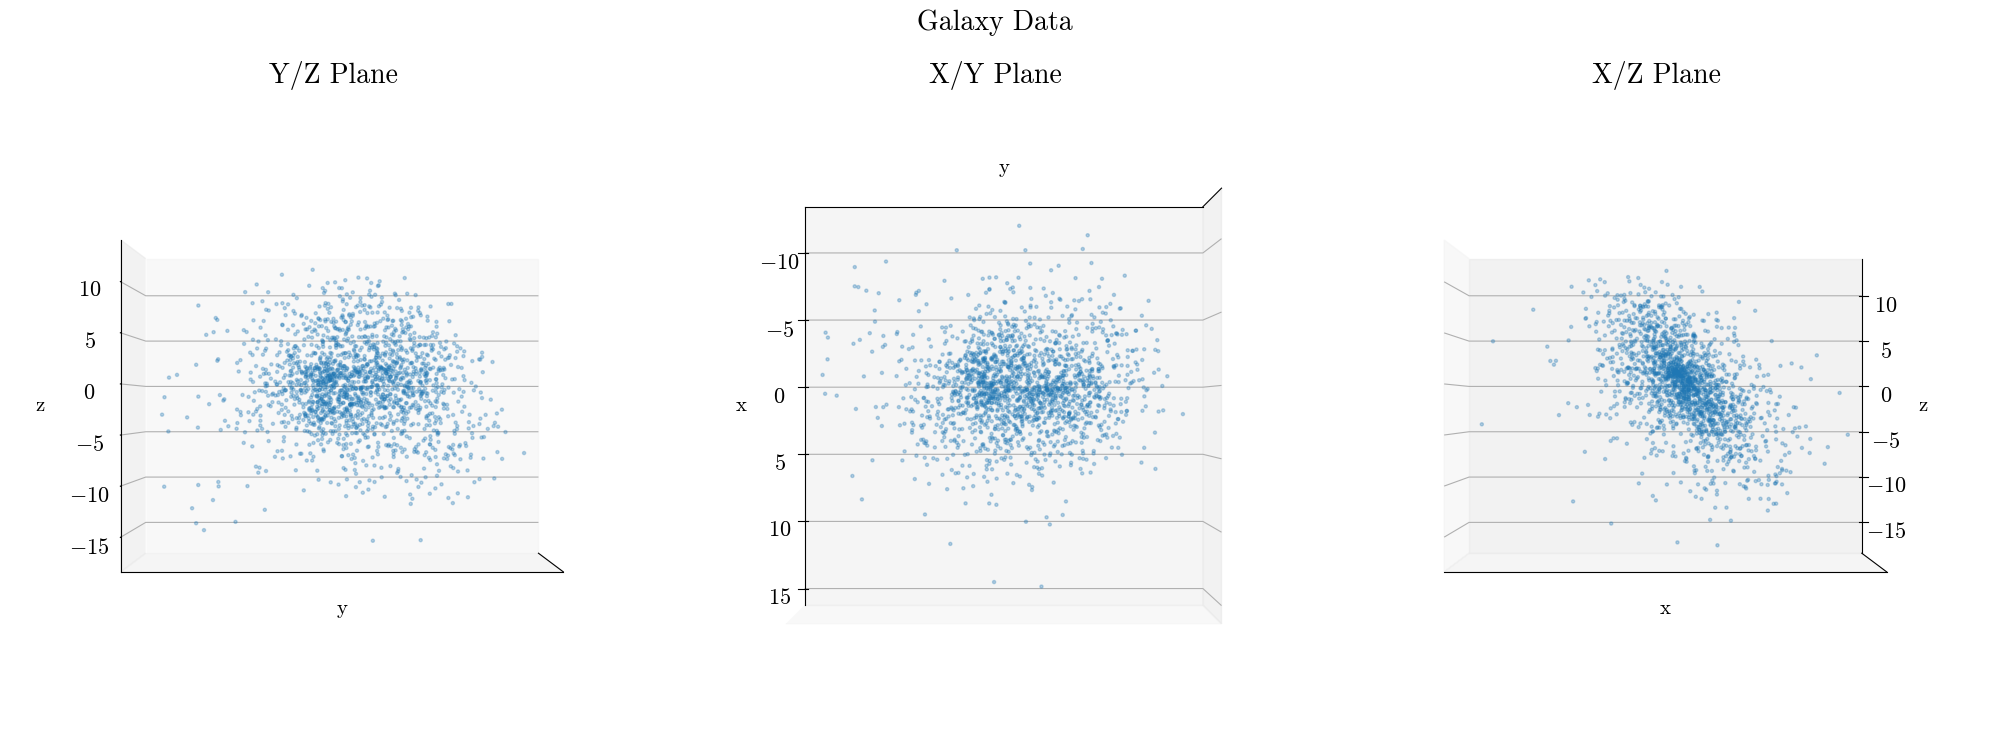

For Galaxy: 162
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_162.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_162.hdf5
202899
166414


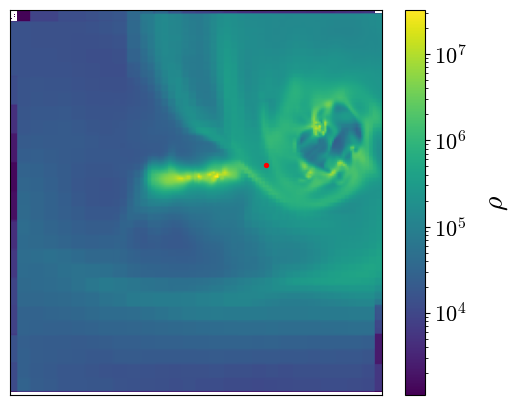

<Figure size 640x480 with 0 Axes>

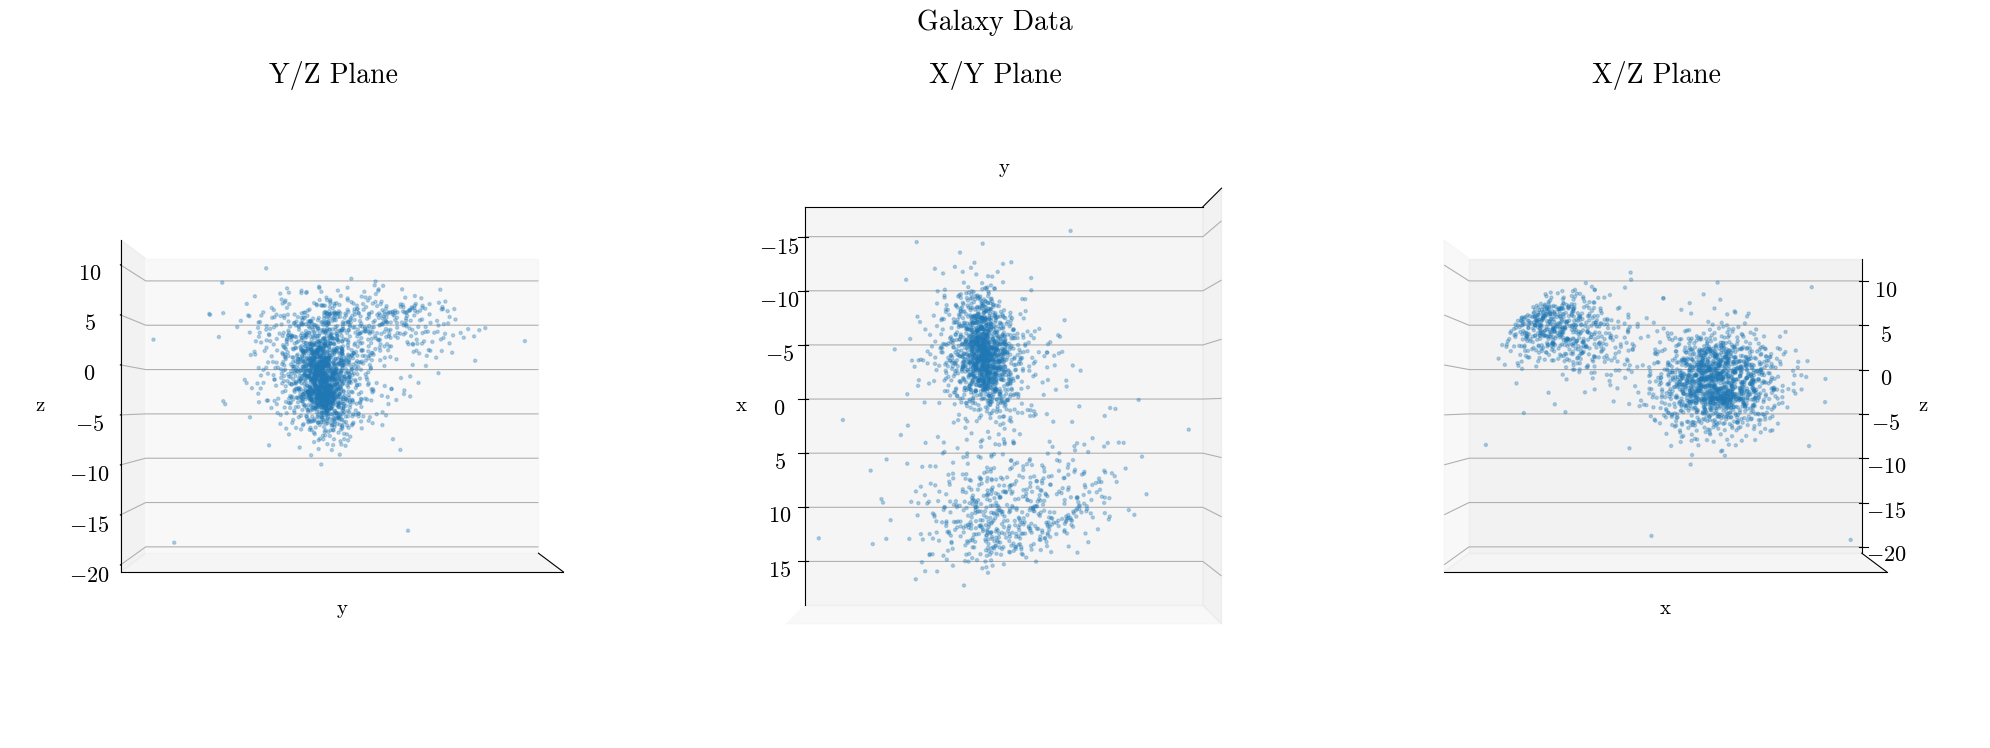

For Galaxy: 2
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_2.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_2.hdf5
9016356
1523482


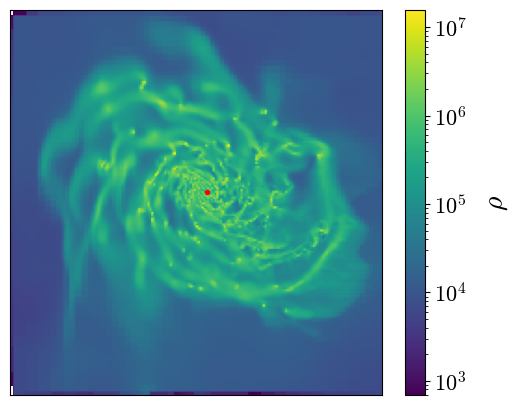

<Figure size 640x480 with 0 Axes>

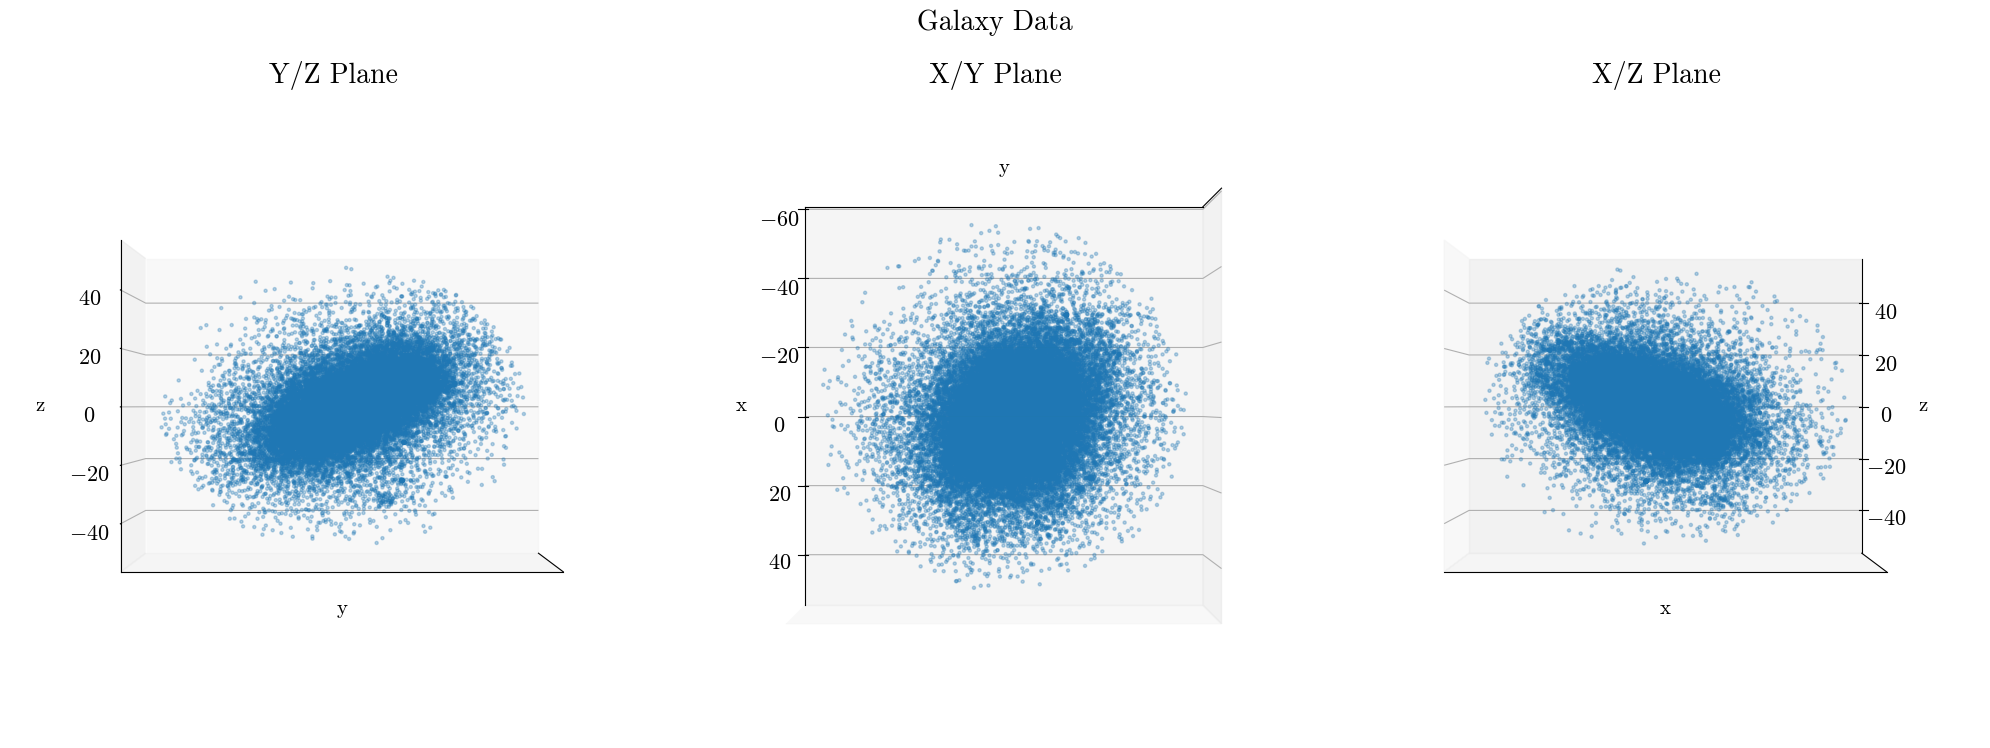

For Galaxy: 112
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_112.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_112.hdf5
1360815
150683


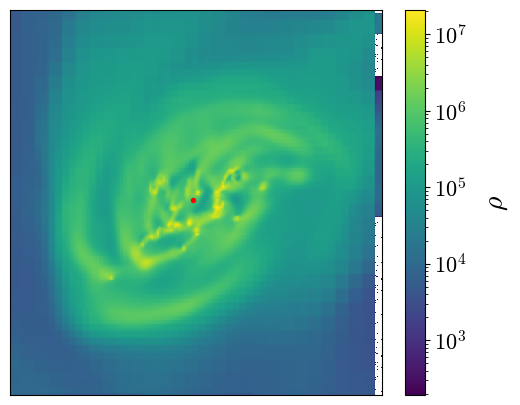

<Figure size 640x480 with 0 Axes>

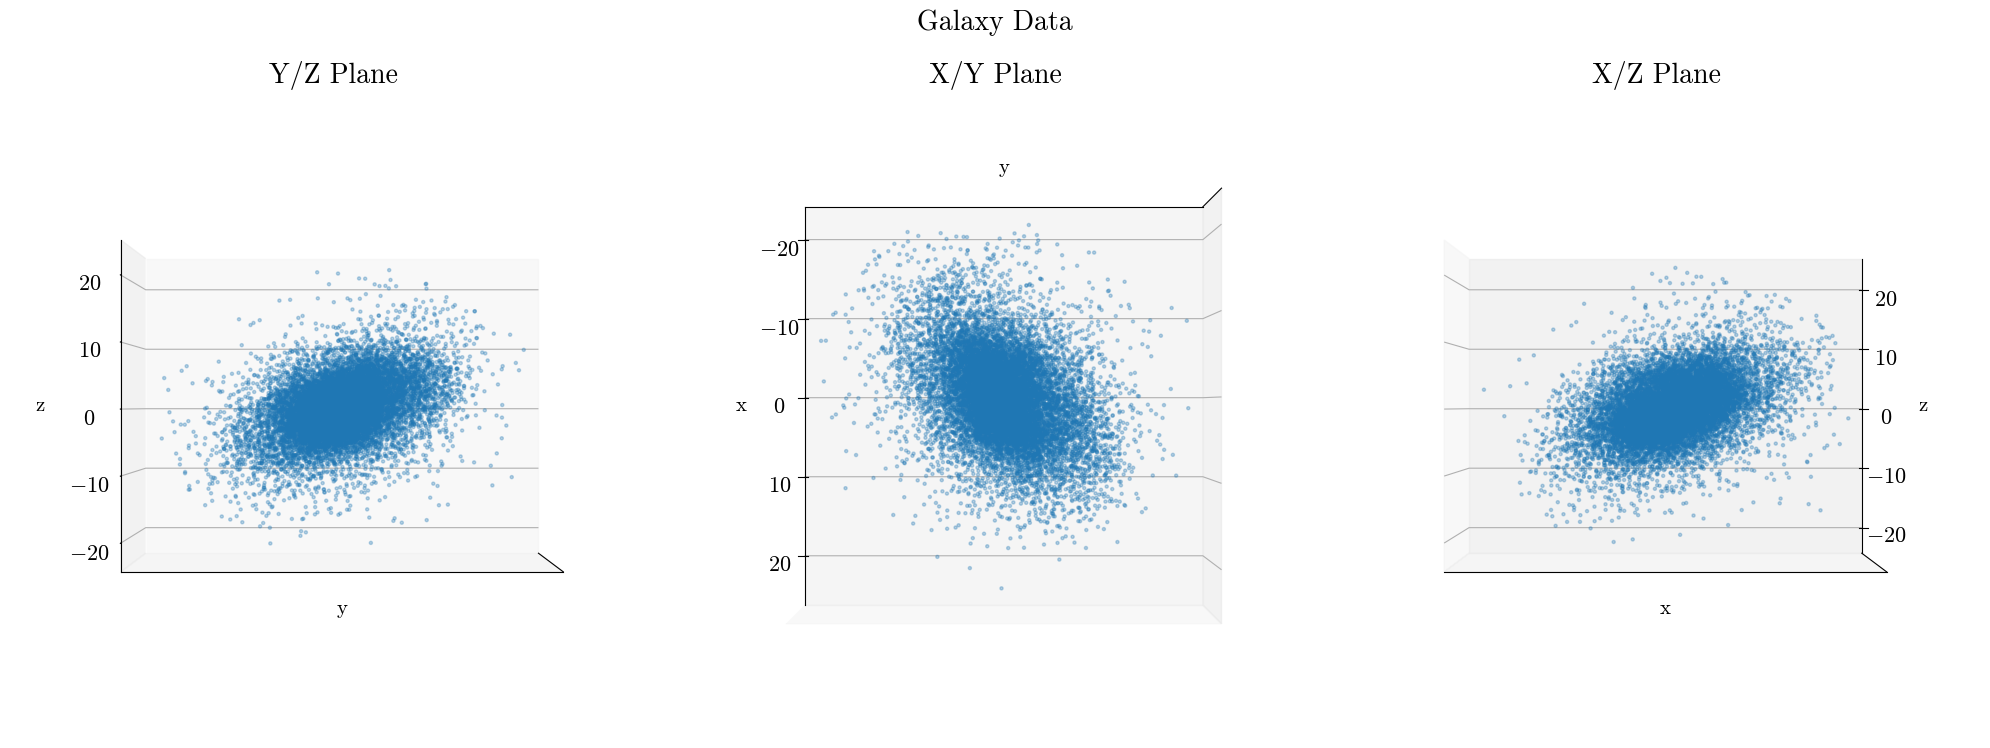

For Galaxy: 594
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_594.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_594.hdf5
4521574
168633


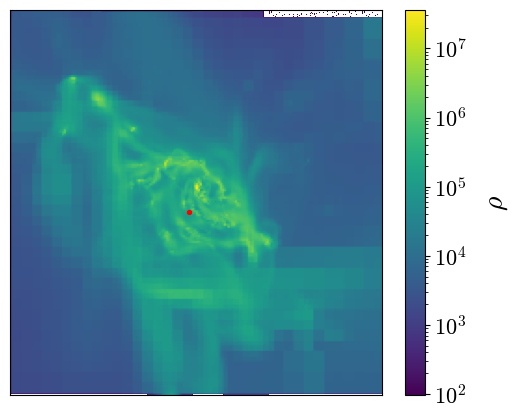

<Figure size 640x480 with 0 Axes>

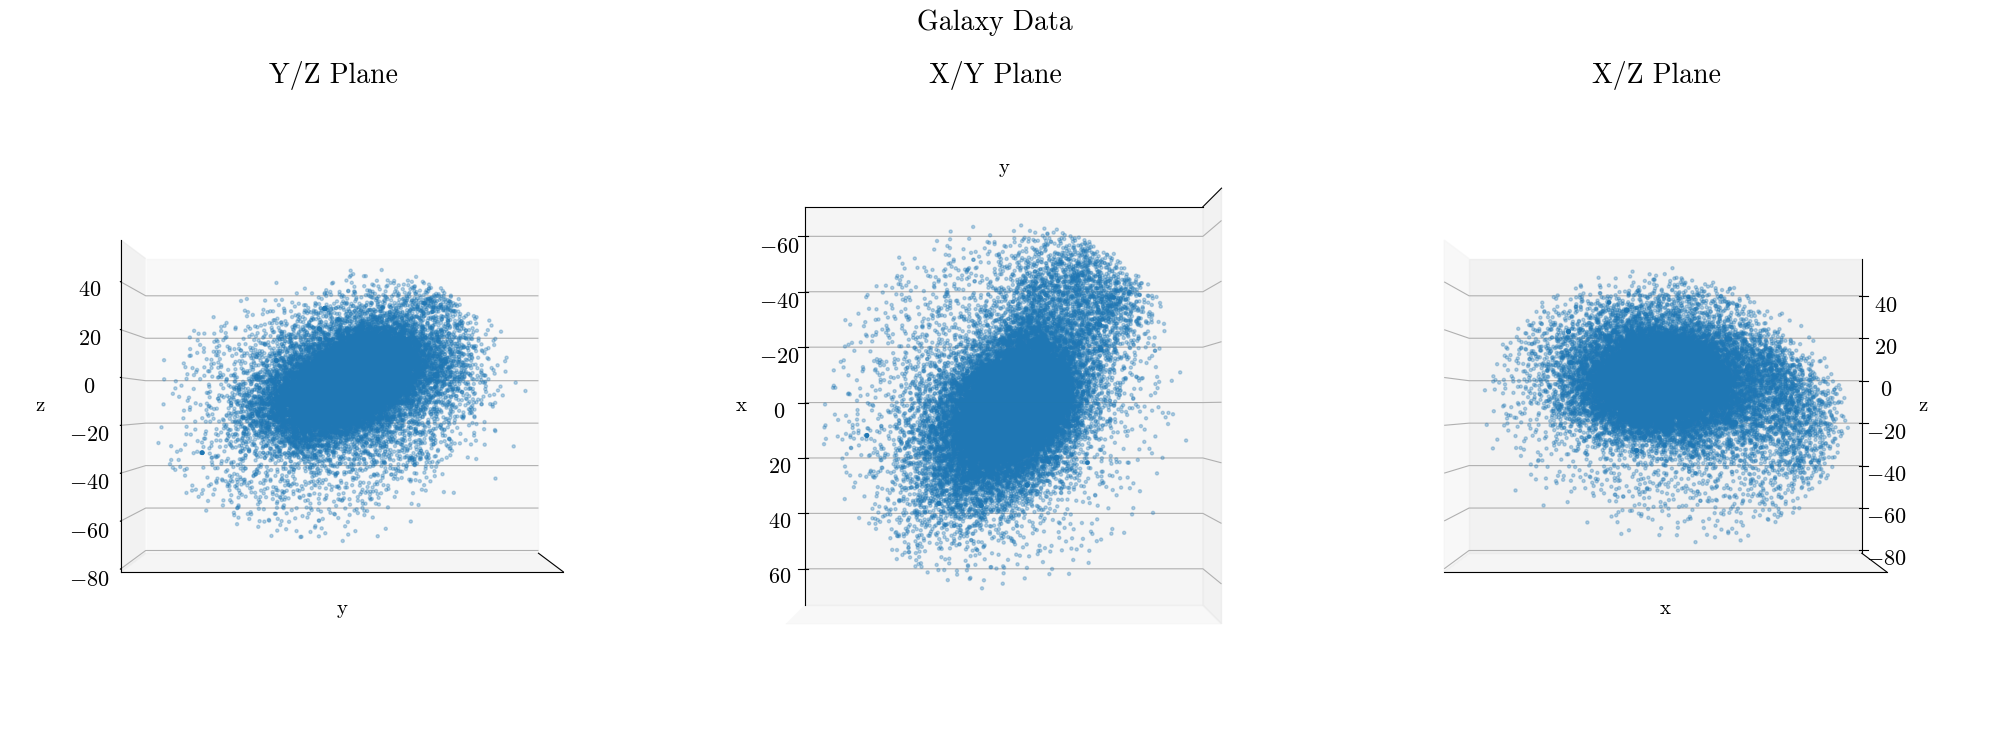

For Galaxy: 185
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/stars_gal_185.hdf5
/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/dm_gal_185.hdf5
60474
5640637


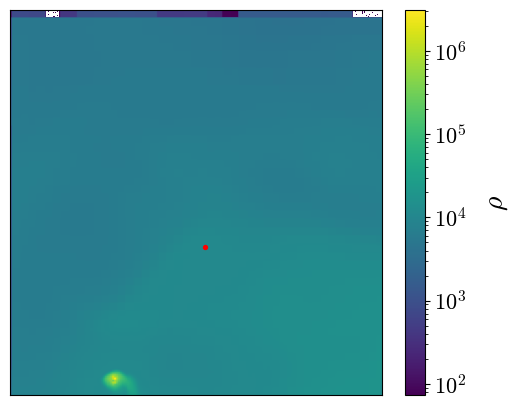

<Figure size 640x480 with 0 Axes>

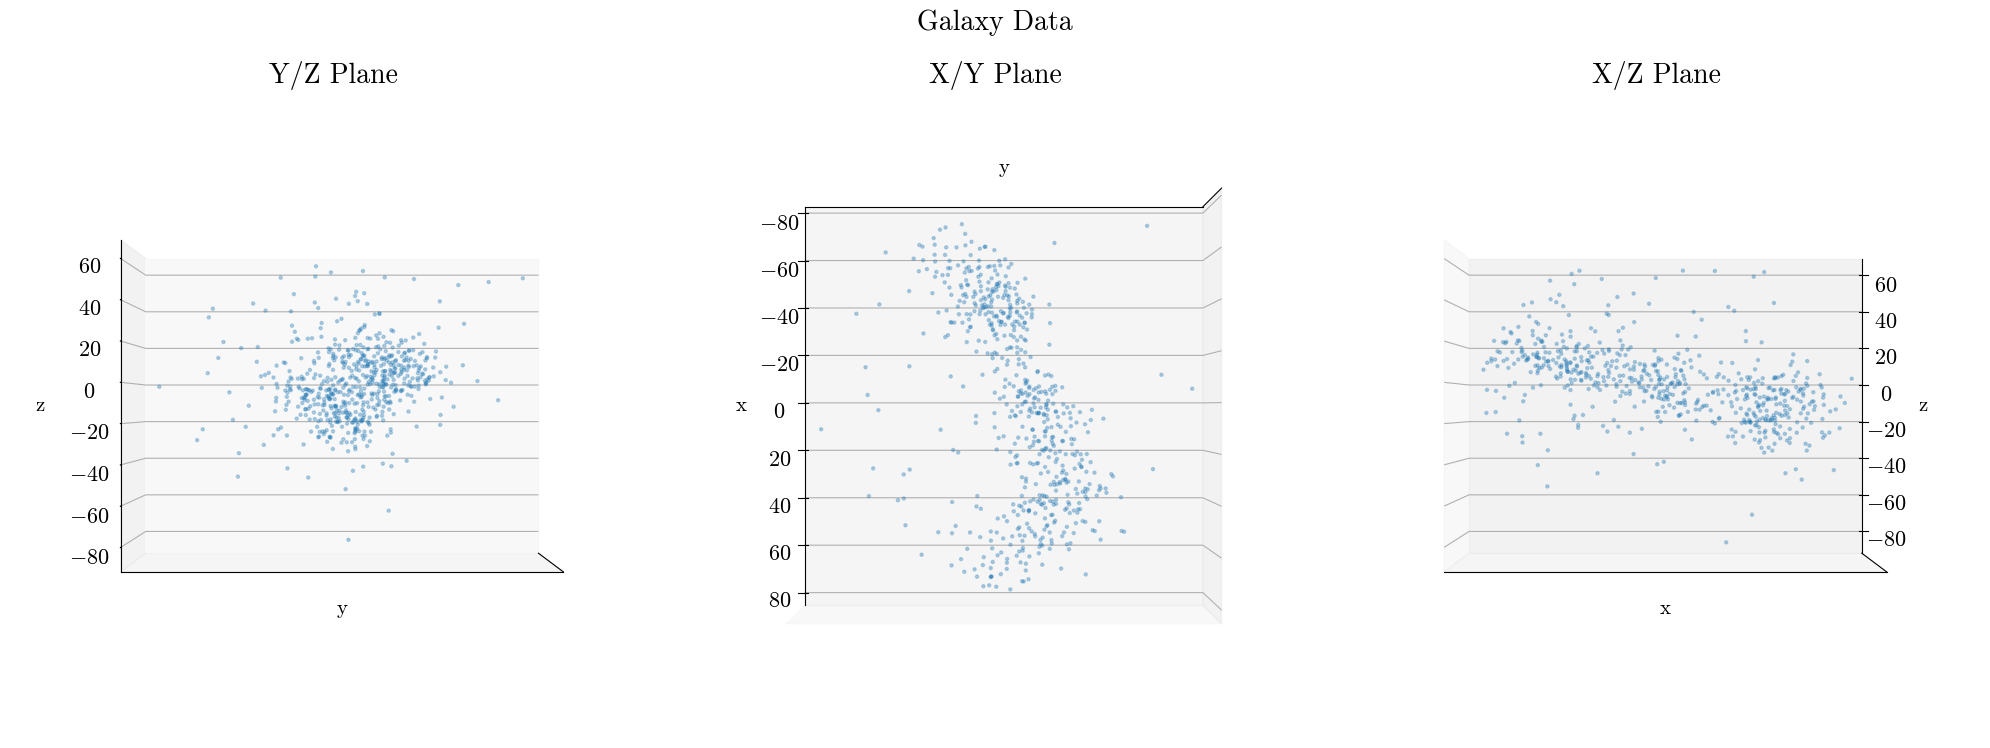

In [7]:

for gal in top_6_gals:

    gal_num = int(gal)

    print('For Galaxy:', gal_num)

    directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/particle_files/'

    stars_files = []
    for filename in glob.glob(os.path.join(directory, '*star*_' + str(gal_num) + '.hdf5')):
        stars_files.append(filename)

    dm_files = []
    for filename in glob.glob(os.path.join(directory, '*dm*_' + str(gal_num) + '.hdf5')):
        dm_files.append(filename)

    from dynamics import load_data

    star_filename = stars_files[0]
    dm_filename = dm_files[0]
    print(star_filename)
    print(dm_filename)

    star_data, dm_data, mass_multiplier, length_multiplier, time_multiplier = load_data(star_filename, dm_filename, ozy_file)



    from dynamics import load_gas_data

    directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/rar/gas_files/'

    files = glob.glob(os.path.join(directory, '*_' + str(gal_num) + '.hdf5'))


    gas_positions, gas_masses, gas_densities, gas_velocities = load_gas_data(files[0], ozy_file)


    xdata = star_data['x'].value
    ydata = star_data['y'].value
    zdata = star_data['z'].value

    vxdata = star_data['vx'].value
    vydata = star_data['vy'].value
    vzdata = star_data['vz'].value

    massdata = star_data['mass'].value

    #DM data

    dm_xdata = dm_data['x'].value
    dm_ydata = dm_data['y'].value
    dm_zdata = dm_data['z'].value

    dm_vxdata = dm_data['vx'].value
    dm_vydata = dm_data['vy'].value
    dm_vzdata = dm_data['vz'].value

    dm_massdata = dm_data['mass'].value

    from dynamics import Plot_3d_scatter



    Plot_3d_scatter(xdata, ydata, zdata, 'x', 'y', 'z', 'Galaxy Data')

In [ ]:
#Fucked up galaxies

fucked_gals = [128, ]


with open('/mnt/users/darnej/MPhys/fucked_gals.txt', 'w') as f:
    for gal in fucked_gals:
        f.write(str(gal) + '\n')

        